# Notebook 04: Model 2 — Anomaly Detection and Diagnosis and Diagnosis and Diagnosis

**Project:** MAP Dryer AI  
**Purpose:** build an unsupervised monitoring model that identifies unusual combinations of MAP dryer operating conditions.

This notebook begins the anomaly-detection workflow. The first three tasks define the modelling objective, load the processed feature table produced by Notebook 02, and select candidate process features.

## 1. Define the anomaly-detection objective

The objective is to detect **multivariate operating conditions that differ materially from normal MAP dryer behaviour**. Each timestamped process record is one observation. The future detector will learn the normal operating envelope from an earlier chronological reference period, assign every new record a continuous anomaly score, and raise a review flag when that score crosses a validated threshold.

The intended users are process operators and engineers investigating developing equipment, control, or process problems. A flag means that the combination of measurements is unusual; it does **not** by itself identify the root cause, prove that product is off specification, or replace existing safety alarms.

### Success criteria

- Detect unusual multivariate operating states early enough for operator review.
- Keep the anomaly score and alarm decision reproducible for each timestamp.
- Limit nuisance alarms through validation, threshold selection, and persistence logic.
- Provide contributing-variable diagnostics so engineers can investigate each flag.
- Use only variables confirmed to be available at inference time; the formal availability and leakage audit is Task 4.

## Setup: import libraries and locate the project root

Load the libraries needed for data handling and later anomaly modelling. The project-root pattern is the same as in the preceding notebooks, so the notebook runs from either the repository root or the `notebooks/` directory.

In [3]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

SRC_DIR = next(
    candidate / "src"
    for candidate in [Path.cwd(), *Path.cwd().parents]
    if (candidate / "data" / "raw").is_dir()
)
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

from data.project_paths import find_project_root

PROJECT_ROOT = find_project_root()
FIGURES_DIR = PROJECT_ROOT / "figures"
FIGURE_OUTPUT_DIR = FIGURES_DIR / "04_Model2_Anomaly"
FIGURE_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

## 2. Load the processed dryer dataset

Read the processed feature table created in Notebook 02 and parse its temporal columns. This uses the same data path and loading code as Notebook 03.

In [4]:
DATA_PATH = PROJECT_ROOT / "data" / "processed" / "dryerMAP_prototype_processed_2.csv"

dryerMAP_model = pd.read_csv(
    DATA_PATH,
    parse_dates=["date", "timestamp"]
)

dryerMAP_model["time"] = dryerMAP_model["time"].astype(str)

display(dryerMAP_model.head())
dryerMAP_model.info()

,date,time,dryer_air_temperature,cooler_air_temperature,air_flow_rate,wet_product_feed_rate,product_inlet_temperature,residence_time,vacuum,steam_pressure,fan_speed,product_density,final_product_temp,final_moisture_h₂o,timestamp,temperature_drop,air_product_delta,air_per_feed,steam_temp_interaction,heating_index
0,2026-04-23,01:00:00,139.0,23.2,23.62,10.00,47.7,20.96,-1.18,4.69,1270.0,1.023,41.0,0.075,2026-04-23 01:00:00,98.0,91.3,2.362000,651.910,2913.440
1,2026-04-23,03:00:00,139.7,21.4,24.32,10.20,46.6,20.29,-0.63,4.78,1236.0,1.028,43.7,0.087,2026-04-23 03:00:00,96.0,93.1,2.384314,667.766,2834.513
2,2026-04-23,05:00:00,140.1,18.9,23.80,10.25,47.3,20.36,-1.08,4.81,1272.0,1.034,45.7,0.072,2026-04-23 05:00:00,94.4,92.8,2.321951,673.881,2852.436
3,2026-04-23,07:00:00,139.7,18.5,23.35,10.27,48.1,20.25,-0.65,4.77,1238.0,1.033,45.2,0.094,2026-04-23 07:00:00,94.5,91.6,2.273612,666.369,2828.925
4,2026-04-23,09:00:00,139.8,19.0,23.44,10.35,46.5,20.99,-1.10,4.84,1267.0,1.025,42.9,0.084,2026-04-23 09:00:00,96.9,93.3,2.264734,676.632,2934.402


<class 'pandas.DataFrame'>
RangeIndex: 1080 entries, 0 to 1079
Data columns (total 20 columns):
 #   Column                     Non-Null Count  Dtype         
---  ------                     --------------  -----         
 0   date                       1080 non-null   datetime64[us]
 1   time                       1080 non-null   str           
 2   dryer_air_temperature      1080 non-null   float64       
 3   cooler_air_temperature     1080 non-null   float64       
 4   air_flow_rate              1080 non-null   float64       
 5   wet_product_feed_rate      1080 non-null   float64       
 6   product_inlet_temperature  1080 non-null   float64       
 7   residence_time             1080 non-null   float64       
 8   vacuum                     1080 non-null   float64       
 9   steam_pressure             1080 non-null   float64       
 10  fan_speed                  1080 non-null   float64       
 11  product_density            1080 non-null   float64       
 12  final_product_tem

## 3. Select candidate anomaly features

Select direct process measurements and the engineered process indicators created in Notebook 02. The list is explicit so every detector input remains auditable. It intentionally focuses on the dryer operating state rather than identifiers or timestamps. Task 4 will formally confirm real-time availability and remove any remaining leakage risk before model training.

In [5]:
DIRECT_PROCESS_FEATURES = [
    "dryer_air_temperature",
    "cooler_air_temperature",
    "air_flow_rate",
    "wet_product_feed_rate",
    "product_inlet_temperature",
    "residence_time",
    "vacuum",
    "steam_pressure",
    "fan_speed",
    "product_density",
    "final_product_temp",
]

ENGINEERED_PROCESS_FEATURES = [
    "temperature_drop",
    "air_product_delta",
    "air_per_feed",
    "steam_temp_interaction",
    "heating_index",
]

ANOMALY_FEATURES = DIRECT_PROCESS_FEATURES + ENGINEERED_PROCESS_FEATURES

missing_features = [
    feature for feature in ANOMALY_FEATURES if feature not in dryerMAP_model.columns
]
if missing_features:
    raise KeyError(f"Selected anomaly features are missing: {missing_features}")

anomaly_feature_catalog = pd.DataFrame(
    {
        "Feature": ANOMALY_FEATURES,
        "Feature group": (
            ["Direct process measurement"] * len(DIRECT_PROCESS_FEATURES)
            + ["Engineered process indicator"] * len(ENGINEERED_PROCESS_FEATURES)
        ),
    }
)

X_anomaly_candidates = dryerMAP_model[ANOMALY_FEATURES].copy()

display(anomaly_feature_catalog)
print(f"Selected candidate features: {len(ANOMALY_FEATURES)}")
print(f"Candidate feature matrix shape: {X_anomaly_candidates.shape}")

,Feature,Feature group
0,dryer_air_temperature,Direct process measurement
1,cooler_air_temperature,Direct process measurement
2,air_flow_rate,Direct process measurement
3,wet_product_feed_rate,Direct process measurement
4,product_inlet_temperature,Direct process measurement
5,residence_time,Direct process measurement
6,vacuum,Direct process measurement
7,steam_pressure,Direct process measurement
8,fan_speed,Direct process measurement
9,product_density,Direct process measurement


Selected candidate features: 16
Candidate feature matrix shape: (1080, 16)


## 4. Remove unavailable and leakage variables

Exclude administrative time fields from the detector inputs and reserve `timestamp` only for chronological ordering and reporting. Exclude `final_moisture_h₂o` because it is a delayed laboratory quality result rather than a real-time process signal. The retained direct measurements are documented PCS7 process variables, and every engineered feature is calculated only from those retained measurements.

In [6]:
EXCLUDED_COLUMNS = {
    "date": "Administrative calendar field; not a process-state measurement.",
    "time": "Administrative clock field; not a process-state measurement.",
    "timestamp": "Retained separately for ordering and reporting only.",
    "final_moisture_h₂o": (
        "Delayed laboratory quality result; unavailable for real-time process detection."
    ),
}

missing_excluded_columns = [
    column for column in EXCLUDED_COLUMNS if column not in dryerMAP_model.columns
]
if missing_excluded_columns:
    raise KeyError(f"Expected excluded columns are missing: {missing_excluded_columns}")

unreviewed_columns = sorted(
    set(dryerMAP_model.columns)
    - set(ANOMALY_FEATURES)
    - set(EXCLUDED_COLUMNS)
)
if unreviewed_columns:
    raise ValueError(f"Columns still require an availability audit: {unreviewed_columns}")

MODEL_FEATURES = [
    feature for feature in ANOMALY_FEATURES if feature not in EXCLUDED_COLUMNS
]
X_anomaly = dryerMAP_model[MODEL_FEATURES].copy()

if not X_anomaly.select_dtypes(exclude="number").empty:
    raise TypeError("All anomaly-model inputs must be numeric.")

availability_leakage_audit = pd.DataFrame(
    [
        {
            "Column": column,
            "Detector input": "No" if column in EXCLUDED_COLUMNS else "Yes",
            "Decision": (
                EXCLUDED_COLUMNS[column]
                if column in EXCLUDED_COLUMNS
                else "Retained real-time process measurement or derived process indicator."
            ),
        }
        for column in dryerMAP_model.columns
    ]
)

display(availability_leakage_audit)
print(f"Final model inputs after audit: {len(MODEL_FEATURES)}")
print("Excluded columns:", list(EXCLUDED_COLUMNS))

,Column,Detector input,Decision
0,date,No,Administrative calendar field; not a process-s...
1,time,No,Administrative clock field; not a process-stat...
2,dryer_air_temperature,Yes,Retained real-time process measurement or deri...
3,cooler_air_temperature,Yes,Retained real-time process measurement or deri...
4,air_flow_rate,Yes,Retained real-time process measurement or deri...
5,wet_product_feed_rate,Yes,Retained real-time process measurement or deri...
6,product_inlet_temperature,Yes,Retained real-time process measurement or deri...
7,residence_time,Yes,Retained real-time process measurement or deri...
8,vacuum,Yes,Retained real-time process measurement or deri...
9,steam_pressure,Yes,Retained real-time process measurement or deri...


Final model inputs after audit: 16
Excluded columns: ['date', 'time', 'timestamp', 'final_moisture_h₂o']


## PCS7 operating-limit configuration (provisional)

The values below are **prototype limits**, based on the observed dataset ranges and outer distributions so the hybrid workflow can be demonstrated. They are deliberately wider than a simple per-feature percentile rule to avoid classifying too many rows as critical when 11 limits are evaluated together. They are not approved PCS7 or safety limits and must be replaced before operational use. `LL` and `HH` represent critical low/high limits; `L` and `H` represent warning limits. Limits are evaluated in original engineering units before scaling. Because `PCS7_LIMITS_APPROVED` is `False`, these demonstration values are displayed in the hybrid results but are not allowed to remove model-training rows.

In [7]:
# PROTOTYPE ONLY: replace these values with approved limits copied from PCS7.
PCS7_LIMIT_CONFIGURATION_MODE = (
    "PROTOTYPE: dataset-range demonstration; not approved for operations"
)
PCS7_LIMITS_APPROVED = False
PCS7_FEATURE_LIMITS = {
    "dryer_air_temperature": {"LL": 136.5, "L": 137.1, "H": 141.6, "HH": 142.5, "unit": "°C"},
    "cooler_air_temperature": {"LL": 18.0, "L": 18.5, "H": 31.9, "HH": 33.0, "unit": "°C"},
    "air_flow_rate": {"LL": 21.2, "L": 22.0, "H": 25.8, "HH": 26.5, "unit": None},
    "wet_product_feed_rate": {"LL": 9.2, "L": 9.37, "H": 10.92, "HH": 11.1, "unit": None},
    "product_inlet_temperature": {"LL": 43.5, "L": 44.4, "H": 51.2, "HH": 51.7, "unit": "°C"},
    "residence_time": {"LL": 18.6, "L": 19.0, "H": 21.94, "HH": 22.5, "unit": None},
    "vacuum": {"LL": -2.2, "L": -1.87, "H": -0.45, "HH": -0.4, "unit": None},
    "steam_pressure": {"LL": 4.3, "L": 4.43, "H": 5.16, "HH": 5.25, "unit": None},
    "fan_speed": {"LL": 1160.0, "L": 1193.0, "H": 1344.0, "HH": 1380.0, "unit": None},
    "product_density": {"LL": 1.008, "L": 1.014, "H": 1.039, "HH": 1.042, "unit": None},
    "final_product_temp": {"LL": 36.0, "L": 37.7, "H": 48.1, "HH": 49.0, "unit": "°C"},
}

LIMIT_ORDER = ["LL", "L", "H", "HH"]
unexpected_limit_features = sorted(
    set(PCS7_FEATURE_LIMITS) - set(DIRECT_PROCESS_FEATURES)
)
if unexpected_limit_features:
    raise KeyError(
        f"PCS7 limits contain unapproved model features: {unexpected_limit_features}"
    )

limit_configuration_rows = []
for feature in DIRECT_PROCESS_FEATURES:
    feature_limits = PCS7_FEATURE_LIMITS[feature]
    configured_pairs = [
        (limit_name, feature_limits[limit_name])
        for limit_name in LIMIT_ORDER
        if feature_limits[limit_name] is not None
    ]
    configured_values = [value for _, value in configured_pairs]
    if configured_values != sorted(configured_values):
        raise ValueError(
            f"PCS7 limits for {feature} must satisfy LL <= L <= H <= HH."
        )
    limit_configuration_rows.append(
        {
            "Feature": feature,
            "LL": feature_limits["LL"],
            "L": feature_limits["L"],
            "H": feature_limits["H"],
            "HH": feature_limits["HH"],
            "Unit": feature_limits["unit"],
            "Configured limits": len(configured_pairs),
        }
    )

pcs7_limit_configuration = pd.DataFrame(limit_configuration_rows).set_index("Feature")
CONFIGURED_PCS7_LIMIT_COUNT = int(
    pcs7_limit_configuration["Configured limits"].sum()
)
CONFIGURED_PCS7_FEATURE_COUNT = int(
    (pcs7_limit_configuration["Configured limits"] > 0).sum()
)


def evaluate_pcs7_limits(process_data, feature_limits):
    limit_results = process_data[["timestamp"]].reset_index(drop=True).copy()
    state_columns = []

    for feature in DIRECT_PROCESS_FEATURES:
        limits = feature_limits[feature]
        values = process_data[feature].reset_index(drop=True)
        state_column = f"{feature} PCS7 state"
        state_columns.append(state_column)

        if all(limits[name] is None for name in LIMIT_ORDER):
            state = np.full(len(values), "Not configured", dtype=object)
        else:
            state = np.full(
                len(values), "Within configured limits", dtype=object
            )
            if limits["L"] is not None:
                state[values < limits["L"]] = "L warning"
            if limits["H"] is not None:
                state[values > limits["H"]] = "H warning"
            if limits["LL"] is not None:
                state[values <= limits["LL"]] = "LL critical"
            if limits["HH"] is not None:
                state[values >= limits["HH"]] = "HH critical"

        limit_results[state_column] = state

    warning_mask = limit_results[state_columns].isin(["L warning", "H warning"])
    critical_mask = limit_results[state_columns].isin(
        ["LL critical", "HH critical"]
    )
    limit_results["PCS7 warning count"] = warning_mask.sum(axis=1)
    limit_results["PCS7 critical count"] = critical_mask.sum(axis=1)
    limit_results["PCS7 breach count"] = (
        limit_results["PCS7 warning count"]
        + limit_results["PCS7 critical count"]
    )
    limit_results["PCS7 rule breach"] = limit_results["PCS7 breach count"] > 0

    breached_feature_labels = []
    for row_index in range(len(limit_results)):
        row_breaches = []
        for feature, state_column in zip(DIRECT_PROCESS_FEATURES, state_columns):
            feature_state = limit_results.at[row_index, state_column]
            if feature_state not in ["Not configured", "Within configured limits"]:
                row_breaches.append(f"{feature}: {feature_state}")
        breached_feature_labels.append("; ".join(row_breaches))
    limit_results["PCS7 breached features"] = breached_feature_labels

    if CONFIGURED_PCS7_LIMIT_COUNT == 0:
        limit_results["PCS7 limit status"] = "Not configured"
    else:
        limit_results["PCS7 limit status"] = np.select(
            [
                limit_results["PCS7 critical count"] > 0,
                limit_results["PCS7 warning count"] > 0,
            ],
            ["Critical", "Warning"],
            default="Within configured limits",
        )
    return limit_results


pcs7_limit_results = evaluate_pcs7_limits(dryerMAP_model, PCS7_FEATURE_LIMITS)
display(pcs7_limit_configuration)
print("PCS7 limit mode:", PCS7_LIMIT_CONFIGURATION_MODE)
print("Approved for training-data filtering:", PCS7_LIMITS_APPROVED)
print(
    f"PCS7 configuration coverage: {CONFIGURED_PCS7_FEATURE_COUNT}/"
    f"{len(DIRECT_PROCESS_FEATURES)} features, "
    f"{CONFIGURED_PCS7_LIMIT_COUNT} individual limits."
)
if CONFIGURED_PCS7_LIMIT_COUNT == 0:
    print(
        "PCS7 rule alarms are disabled until approved limits replace the None values."
    )

,LL,L,H,HH,Unit,Configured limits
Feature,,,,,,
dryer_air_temperature,136.500,137.100,141.600,142.500,°C,4
cooler_air_temperature,18.000,18.500,31.900,33.000,°C,4
air_flow_rate,21.200,22.000,25.800,26.500,NaN,4
wet_product_feed_rate,9.200,9.370,10.920,11.100,NaN,4
product_inlet_temperature,43.500,44.400,51.200,51.700,°C,4
residence_time,18.600,19.000,21.940,22.500,NaN,4
vacuum,-2.200,-1.870,-0.450,-0.400,NaN,4
steam_pressure,4.300,4.430,5.160,5.250,NaN,4
fan_speed,1160.000,1193.000,1344.000,1380.000,NaN,4


PCS7 limit mode: PROTOTYPE: dataset-range demonstration; not approved for operations
Approved for training-data filtering: False
PCS7 configuration coverage: 11/11 features, 44 individual limits.


## 5. Inspect retained feature distributions

Review descriptive statistics and univariate distributions before defining the normal reference period. These plots reveal scale differences, skew, long tails, and possible data-quality issues; unusual tails are not automatically treated as anomalies at this stage because operating context still matters.

,count,missing values,non-finite values,mean,std,min,25%,50%,75%,max,skewness
dryer_air_temperature,1080.0,0,0,139.3990,1.1026,136.3000,138.5000,139.4000,140.2000,142.8000,0.0088
cooler_air_temperature,1080.0,0,0,24.2626,3.4003,18.5000,21.5000,24.3000,26.7000,33.3000,0.1338
air_flow_rate,1080.0,0,0,23.8650,0.8460,21.0100,23.2500,23.8500,24.4325,27.0000,0.1207
wet_product_feed_rate,1080.0,0,0,10.1518,0.4017,9.1600,9.8200,10.1500,10.4700,11.1800,0.0151
product_inlet_temperature,1080.0,0,0,47.7766,1.5305,43.2000,46.7000,47.7000,48.8000,51.9000,0.0269
residence_time,1080.0,0,0,20.5669,0.6563,18.4500,20.1100,20.5900,21.0025,22.6900,-0.1313
vacuum,1080.0,0,0,-0.9975,0.3451,-2.3000,-1.2300,-0.9800,-0.7200,-0.4500,-0.3685
steam_pressure,1080.0,0,0,4.7890,0.1630,4.2700,4.6800,4.7900,4.9000,5.3000,0.0005
fan_speed,1080.0,0,0,1264.7259,32.4984,1148.0000,1241.0000,1263.5000,1288.0000,1392.0000,0.1195
product_density,1080.0,0,0,1.0265,0.0052,1.0070,1.0230,1.0260,1.0300,1.0410,-0.0465


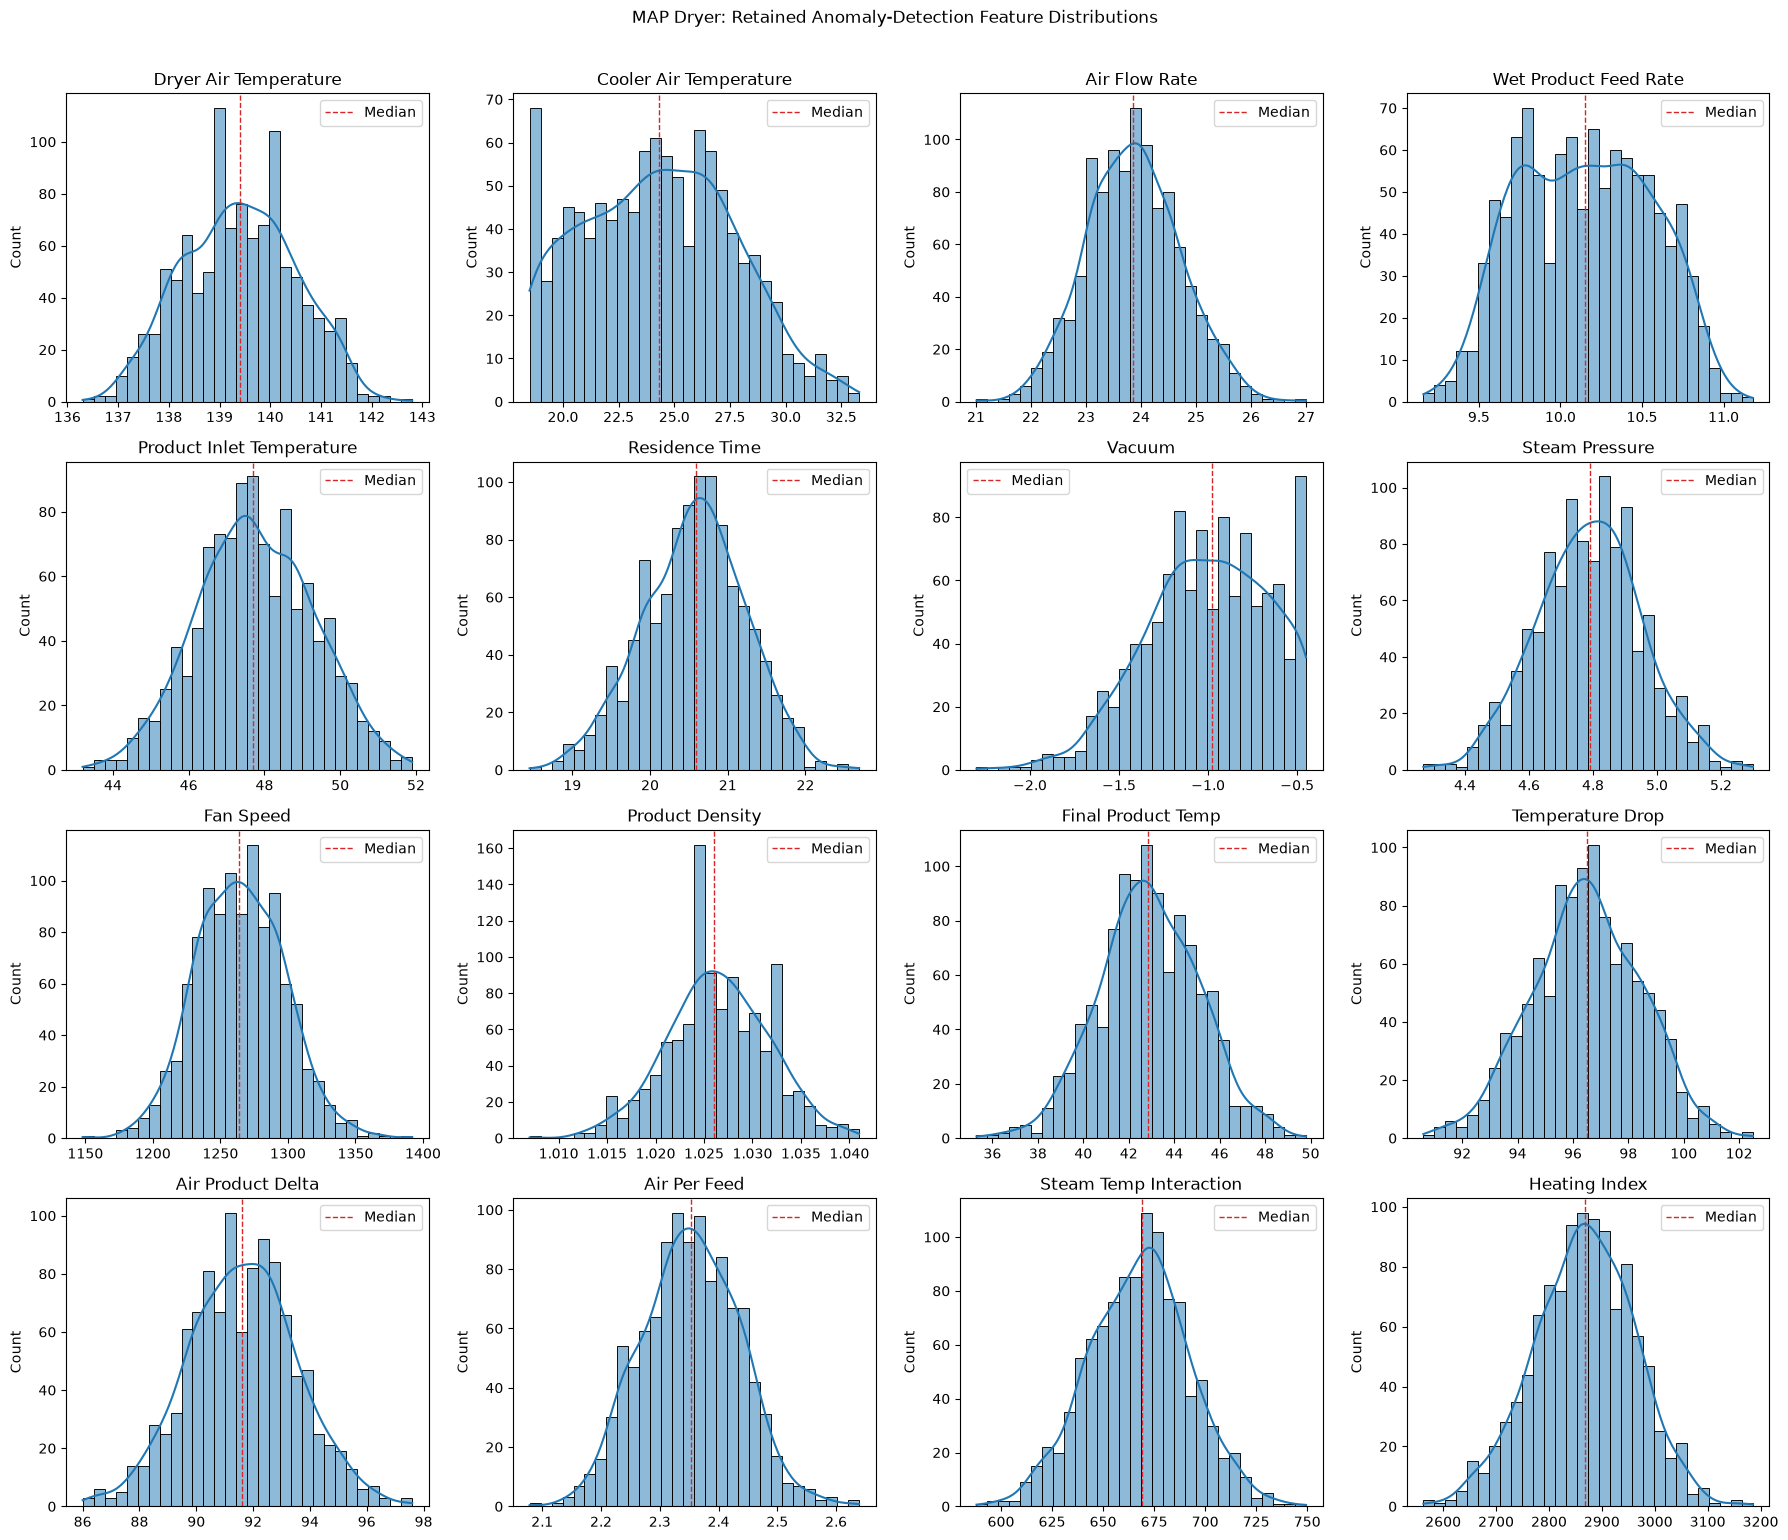

In [8]:
distribution_summary = X_anomaly.describe().T
distribution_summary["missing values"] = X_anomaly.isna().sum()
distribution_summary["non-finite values"] = (
    ~np.isfinite(X_anomaly)
).sum()
distribution_summary["skewness"] = X_anomaly.skew()
distribution_summary = distribution_summary[
    [
        "count",
        "missing values",
        "non-finite values",
        "mean",
        "std",
        "min",
        "25%",
        "50%",
        "75%",
        "max",
        "skewness",
    ]
]
display(distribution_summary.round(4))

n_columns = 4
n_rows = int(np.ceil(len(MODEL_FEATURES) / n_columns))
fig, axes = plt.subplots(n_rows, n_columns, figsize=(18, 3.8 * n_rows))
axes = np.asarray(axes).reshape(-1)

for axis, feature in zip(axes, MODEL_FEATURES):
    sns.histplot(
        X_anomaly[feature],
        bins=30,
        kde=True,
        color="tab:blue",
        ax=axis,
    )
    axis.axvline(
        X_anomaly[feature].median(),
        color="tab:red",
        linestyle="--",
        linewidth=1,
        label="Median",
    )
    axis.set_title(feature.replace("_", " " ).title())
    axis.set_xlabel("")
    axis.legend()

for axis in axes[len(MODEL_FEATURES):]:
    axis.set_visible(False)

fig.suptitle("MAP Dryer: Retained Anomaly-Detection Feature Distributions", y=1.01)
fig.tight_layout()
fig.savefig(
    FIGURE_OUTPUT_DIR / "01_retained_feature_distributions.png",
    dpi=300,
    bbox_inches="tight",
)
plt.show()

## 6. Create chronological train, validation, and test sets

Sort records by timestamp and allocate the earliest 60% to training, the next 20% to validation, and the most recent 20% to testing. No rows are shuffled. This preserves temporal order, prevents future observations from entering the training period, and leaves two later periods for threshold selection and final evaluation.

In [9]:
TRAIN_FRACTION = 0.60
VALIDATION_FRACTION = 0.20

ordered_anomaly_data = (
    dryerMAP_model[["timestamp", *MODEL_FEATURES]]
    .sort_values("timestamp", kind="stable")
    .reset_index(drop=True)
)

if ordered_anomaly_data["timestamp"].isna().any():
    raise ValueError("Chronological splitting requires complete timestamps.")
if ordered_anomaly_data["timestamp"].duplicated().any():
    raise ValueError("Chronological splitting requires unique timestamps.")

n_observations = len(ordered_anomaly_data)
train_end = int(n_observations * TRAIN_FRACTION)
validation_end = train_end + int(n_observations * VALIDATION_FRACTION)

train_data = ordered_anomaly_data.iloc[:train_end].copy()
validation_data = ordered_anomaly_data.iloc[train_end:validation_end].copy()
test_data = ordered_anomaly_data.iloc[validation_end:].copy()

X_train = train_data[MODEL_FEATURES].copy()
X_validation = validation_data[MODEL_FEATURES].copy()
X_test = test_data[MODEL_FEATURES].copy()

train_timestamps = train_data["timestamp"].copy()
validation_timestamps = validation_data["timestamp"].copy()
test_timestamps = test_data["timestamp"].copy()

if not (
    train_timestamps.max() < validation_timestamps.min()
    and validation_timestamps.max() < test_timestamps.min()
):
    raise AssertionError("The chronological split boundaries overlap.")
if len(X_train) + len(X_validation) + len(X_test) != n_observations:
    raise AssertionError("The chronological split lost or duplicated observations.")

split_summary = pd.DataFrame(
    {
        "Rows": [len(train_data), len(validation_data), len(test_data)],
        "Share (%)": [
            100 * len(train_data) / n_observations,
            100 * len(validation_data) / n_observations,
            100 * len(test_data) / n_observations,
        ],
        "Start timestamp": [
            train_timestamps.min(),
            validation_timestamps.min(),
            test_timestamps.min(),
        ],
        "End timestamp": [
            train_timestamps.max(),
            validation_timestamps.max(),
            test_timestamps.max(),
        ],
    },
    index=["Training", "Validation", "Testing"],
)

display(split_summary.round({"Share (%)": 2}))

,Rows,Share (%),Start timestamp,End timestamp
Training,648,60.0,2026-04-23 01:00:00,2026-06-15 23:00:00
Validation,216,20.0,2026-06-16 01:00:00,2026-07-03 23:00:00
Testing,216,20.0,2026-07-04 01:00:00,2026-07-21 23:00:00


## 7. Define the normal reference training data

No confirmed fault-event labels are available in the processed dataset. Therefore, use the earliest chronological training period as the provisional representation of normal operation after enforcing missing-value and finite-value checks. PCS7 breaches are excluded only when `PCS7_LIMITS_APPROVED` is explicitly set to `True`; prototype limits must never silently narrow the learned normal envelope. Do not remove other statistically extreme but valid observations without operator evidence, because doing so can increase nuisance alarms. The operational threshold is selected separately using validation data.

This assumption should be revisited when operator logs, maintenance records, or confirmed abnormal operating windows become available.

In [10]:
finite_training_rows = pd.Series(
    np.isfinite(X_train).all(axis=1),
    index=X_train.index,
    name="finite_values",
)
complete_training_rows = X_train.notna().all(axis=1)
training_pcs7_status = (
    train_data[["timestamp"]]
    .merge(
        pcs7_limit_results[
            ["timestamp", "PCS7 rule breach", "PCS7 limit status"]
        ],
        on="timestamp",
        how="left",
        validate="one_to_one",
    )
    .set_axis(X_train.index)
)
prototype_pcs7_breach_rows = training_pcs7_status["PCS7 rule breach"]
if PCS7_LIMITS_APPROVED:
    pcs7_reference_eligible_rows = ~prototype_pcs7_breach_rows
else:
    pcs7_reference_eligible_rows = pd.Series(
        True, index=X_train.index, name="PCS7 reference eligible"
    )
normal_reference_mask = (
    finite_training_rows & complete_training_rows & pcs7_reference_eligible_rows
)

X_normal_reference = X_train.loc[normal_reference_mask].copy()
normal_reference_timestamps = train_timestamps.loc[normal_reference_mask].copy()

if X_normal_reference.empty:
    raise ValueError("No valid rows remain for the normal reference period.")
if list(X_normal_reference.columns) != MODEL_FEATURES:
    raise AssertionError("Normal reference features do not match MODEL_FEATURES.")

normal_reference_summary = pd.DataFrame(
    {
        "Rows": [len(X_train), len(X_normal_reference)],
        "Share of training (%)": [
            100.0,
            100 * len(X_normal_reference) / len(X_train),
        ],
        "Start timestamp": [
            train_timestamps.min(),
            normal_reference_timestamps.min(),
        ],
        "End timestamp": [
            train_timestamps.max(),
            normal_reference_timestamps.max(),
        ],
    },
    index=["Chronological training period", "Normal reference after quality checks"],
)

display(normal_reference_summary.round({"Share of training (%)": 2}))
print(
    "Rows removed by missing/non-finite checks:",
    int((~(finite_training_rows & complete_training_rows)).sum()),
)
print(
    "Training rows that breach the displayed prototype limits:",
    int(prototype_pcs7_breach_rows.sum()),
)
print(
    "Rows removed by approved PCS7 limits:",
    int((~pcs7_reference_eligible_rows).sum()),
)
if not PCS7_LIMITS_APPROVED:
    print("Prototype PCS7 limits did not influence model fitting.")

,Rows,Share of training (%),Start timestamp,End timestamp
Chronological training period,648,100.0,2026-04-23 01:00:00,2026-06-15 23:00:00
Normal reference after quality checks,648,100.0,2026-04-23 01:00:00,2026-06-15 23:00:00


Rows removed by missing/non-finite checks: 0
Training rows that breach the displayed prototype limits: 96
Rows removed by approved PCS7 limits: 0
Prototype PCS7 limits did not influence model fitting.


## 8. Scale features

Fit a standard scaler only on the normal reference data, then apply the learned transformation to validation and test data without refitting. Isolation Forest does not strictly require standardized units, but a shared scaled representation supports later detector comparison and contributing-variable diagnostics while preventing future-period leakage.

In [11]:
from sklearn.preprocessing import StandardScaler

anomaly_scaler = StandardScaler()

X_normal_reference_scaled = pd.DataFrame(
    anomaly_scaler.fit_transform(X_normal_reference),
    columns=MODEL_FEATURES,
    index=X_normal_reference.index,
)
X_train_scaled = pd.DataFrame(
    anomaly_scaler.transform(X_train),
    columns=MODEL_FEATURES,
    index=X_train.index,
)
X_validation_scaled = pd.DataFrame(
    anomaly_scaler.transform(X_validation),
    columns=MODEL_FEATURES,
    index=X_validation.index,
)
X_test_scaled = pd.DataFrame(
    anomaly_scaler.transform(X_test),
    columns=MODEL_FEATURES,
    index=X_test.index,
)

scaling_summary = pd.DataFrame(
    {
        "Reference raw mean": X_normal_reference.mean(),
        "Reference raw std": X_normal_reference.std(ddof=0),
        "Reference scaled mean": X_normal_reference_scaled.mean(),
        "Reference scaled std": X_normal_reference_scaled.std(ddof=0),
    }
)

if not np.allclose(X_normal_reference_scaled.mean(), 0.0, atol=1e-10):
    raise AssertionError("Scaled reference features are not centered at zero.")
if not np.allclose(X_normal_reference_scaled.std(ddof=0), 1.0, atol=1e-10):
    raise AssertionError("Scaled reference features do not have unit variance.")

display(scaling_summary.round(4))
print("Scaler fitted on normal reference rows only.")

,Reference raw mean,Reference raw std,Reference scaled mean,Reference scaled std
dryer_air_temperature,139.4719,1.1246,0.0,1.0
cooler_air_temperature,23.3715,3.0871,-0.0,1.0
air_flow_rate,23.7929,0.8250,-0.0,1.0
wet_product_feed_rate,10.1737,0.4142,0.0,1.0
product_inlet_temperature,47.5377,1.4574,-0.0,1.0
residence_time,20.5451,0.6695,0.0,1.0
vacuum,-0.9664,0.3389,0.0,1.0
steam_pressure,4.7961,0.1655,0.0,1.0
fan_speed,1261.7176,31.9861,-0.0,1.0
product_density,1.0268,0.0053,0.0,1.0


Scaler fitted on normal reference rows only.


## 9. Train Isolation Forest

Fit an Isolation Forest on the scaled normal reference period. The model uses 300 trees and a fixed random seed for reproducibility. `contamination="auto"` is retained during fitting because the operational anomaly threshold is deliberately deferred to Task 11; the estimator's built-in class labels are not used as final alarms.

In [12]:
from sklearn.ensemble import IsolationForest

isolation_forest_model = IsolationForest(
    n_estimators=300,
    max_samples="auto",
    contamination="auto",
    max_features=1.0,
    bootstrap=False,
    random_state=42,
    n_jobs=-1,
)
isolation_forest_model.fit(X_normal_reference_scaled)

isolation_forest_training_summary = pd.Series(
    {
        "Training rows": len(X_normal_reference_scaled),
        "Features": X_normal_reference_scaled.shape[1],
        "Trees fitted": len(isolation_forest_model.estimators_),
        "Maximum samples per tree": isolation_forest_model.max_samples_,
        "Contamination setting": isolation_forest_model.contamination,
        "Random state": isolation_forest_model.random_state,
    },
    name="Isolation Forest",
)

display(isolation_forest_training_summary.to_frame())
print("Isolation Forest fitted; scoring and threshold selection remain separate.")

,Isolation Forest
Training rows,648
Features,16
Trees fitted,300
Maximum samples per tree,256
Contamination setting,auto
Random state,42


Isolation Forest fitted; scoring and threshold selection remain separate.


## 10. Generate anomaly scores

Generate a continuous score for every reference, validation, and test observation. Isolation Forest's native `score_samples` output becomes smaller as an observation becomes more unusual, so multiply it by -1 to create an intuitive anomaly score where **larger values indicate more anomalous operating conditions**. No threshold or alarm label is applied in this step.

In [13]:
def build_anomaly_score_table(split_name, timestamps, scaled_features):
    anomaly_scores = -isolation_forest_model.score_samples(
        scaled_features[MODEL_FEATURES]
    )
    return pd.DataFrame(
        {
            "timestamp": timestamps.to_numpy(),
            "Split": split_name,
            "Anomaly score": anomaly_scores,
        }
    )


anomaly_score_results = (
    pd.concat(
        [
            build_anomaly_score_table(
                "Reference",
                train_timestamps,
                X_train_scaled,
            ),
            build_anomaly_score_table(
                "Validation",
                validation_timestamps,
                X_validation_scaled,
            ),
            build_anomaly_score_table(
                "Testing",
                test_timestamps,
                X_test_scaled,
            ),
        ],
        ignore_index=True,
    )
    .sort_values("timestamp", kind="stable")
    .reset_index(drop=True)
)

score_distribution_summary = (
    anomaly_score_results.groupby("Split", sort=False)["Anomaly score"]
    .describe(percentiles=[0.50, 0.95, 0.99])
    [["count", "mean", "std", "min", "50%", "95%", "99%", "max"]]
)

if anomaly_score_results["Anomaly score"].isna().any():
    raise ValueError("Anomaly scoring produced missing values.")

display(score_distribution_summary.round(5))
print("Score direction: higher values indicate more unusual observations.")

,count,mean,std,min,50%,95%,99%,max
Split,,,,,,,,
Reference,648.0,0.44995,0.03663,0.38632,0.44515,0.52085,0.54953,0.57582
Validation,216.0,0.45594,0.04088,0.38590,0.44777,0.53143,0.56872,0.62833
Testing,216.0,0.46020,0.04707,0.38196,0.44855,0.54638,0.60370,0.61633


Score direction: higher values indicate more unusual observations.


## 11. Define the anomaly threshold

Use finite-sample split-conformal calibration on the validation anomaly scores, targeting a 1% raw review rate. Unlike an interpolated percentile, the conformal order statistic is explicit and reproducible for this validation set of only 216 observations. The test scores are never used to choose the threshold. Because confirmed anomaly labels are unavailable, 1% is still an operating assumption rather than a proven optimum; persistence is added in Task 15.

In [14]:
TARGET_VALIDATION_CANDIDATE_RATE = 0.01

def calibrate_conformal_threshold(calibration_scores, target_candidate_rate):
    scores = np.asarray(calibration_scores, dtype=float)
    if scores.ndim != 1 or len(scores) == 0 or not np.isfinite(scores).all():
        raise ValueError("Calibration scores must be a finite non-empty vector.")
    if not 0 < target_candidate_rate < 1:
        raise ValueError("Target candidate rate must lie strictly between 0 and 1.")
    order_rank = int(
        np.ceil((len(scores) + 1) * (1 - target_candidate_rate))
    )
    order_rank = min(max(order_rank, 1), len(scores))
    return float(np.sort(scores)[order_rank - 1]), order_rank


validation_anomaly_scores = anomaly_score_results.loc[
    anomaly_score_results["Split"] == "Validation",
    "Anomaly score",
]
ANOMALY_THRESHOLD, BASELINE_THRESHOLD_ORDER_RANK = calibrate_conformal_threshold(
    validation_anomaly_scores, TARGET_VALIDATION_CANDIDATE_RATE
)

anomaly_score_results["Raw anomaly flag"] = (
    anomaly_score_results["Anomaly score"] >= ANOMALY_THRESHOLD
)

threshold_evaluation = (
    anomaly_score_results.groupby("Split", sort=False)
    .agg(
        Observations=("Raw anomaly flag", "size"),
        Raw_anomaly_candidates=("Raw anomaly flag", "sum"),
        Minimum_score=("Anomaly score", "min"),
        Maximum_score=("Anomaly score", "max"),
    )
)
threshold_evaluation["Raw candidate rate (%)"] = (
    100
    * threshold_evaluation["Raw_anomaly_candidates"]
    / threshold_evaluation["Observations"]
)

display(threshold_evaluation.round(4))
print(
    f"Finite-sample threshold targeting "
    f"{TARGET_VALIDATION_CANDIDATE_RATE:.1%} validation candidates: "
    f"{ANOMALY_THRESHOLD:.5f} (order rank {BASELINE_THRESHOLD_ORDER_RANK}/"
    f"{len(validation_anomaly_scores)})"
)

,Observations,Raw_anomaly_candidates,Minimum_score,Maximum_score,Raw candidate rate (%)
Split,,,,,
Reference,648,0,0.3863,0.5758,0.0000
Validation,216,2,0.3859,0.6283,0.9259
Testing,216,4,0.3820,0.6163,1.8519


Finite-sample threshold targeting 1.0% validation candidates: 0.59630 (order rank 215/216)


## 12. Visualize anomalies through time

Plot the continuous anomaly score across the complete chronological record. Points above the validated threshold are highlighted as raw anomaly candidates. They are investigation candidates only—not persistent operator alarms—and the colors identify which observations belong to the reference, validation, and untouched test periods.

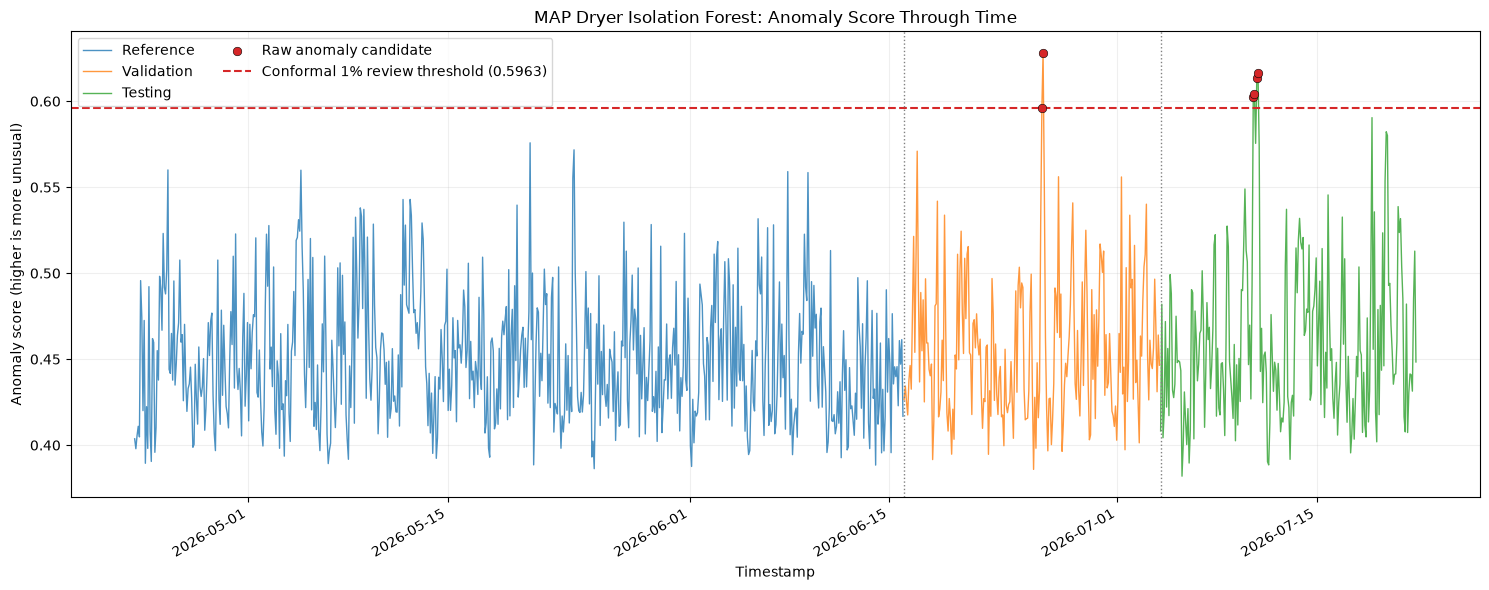

In [15]:
split_colors = {
    "Reference": "tab:blue",
    "Validation": "tab:orange",
    "Testing": "tab:green",
}

fig, axis = plt.subplots(figsize=(15, 6))
for split_name, split_color in split_colors.items():
    split_scores = anomaly_score_results.loc[
        anomaly_score_results["Split"] == split_name
    ]
    axis.plot(
        split_scores["timestamp"],
        split_scores["Anomaly score"],
        color=split_color,
        linewidth=1.0,
        alpha=0.8,
        label=split_name,
    )

raw_anomaly_candidates = anomaly_score_results.loc[
    anomaly_score_results["Raw anomaly flag"]
]
axis.scatter(
    raw_anomaly_candidates["timestamp"],
    raw_anomaly_candidates["Anomaly score"],
    color="tab:red",
    edgecolor="black",
    linewidth=0.4,
    s=38,
    zorder=4,
    label="Raw anomaly candidate",
)
axis.axhline(
    ANOMALY_THRESHOLD,
    color="tab:red",
    linestyle="--",
    linewidth=1.5,
    label=f"Conformal 1% review threshold ({ANOMALY_THRESHOLD:.4f})",
)
axis.axvline(
    validation_timestamps.min(),
    color="grey",
    linestyle=":",
    linewidth=1,
)
axis.axvline(
    test_timestamps.min(),
    color="grey",
    linestyle=":",
    linewidth=1,
)
axis.set_title("MAP Dryer Isolation Forest: Anomaly Score Through Time")
axis.set_xlabel("Timestamp")
axis.set_ylabel("Anomaly score (higher is more unusual)")
axis.grid(alpha=0.2)
axis.legend(loc="upper left", ncol=2)
fig.autofmt_xdate()
fig.tight_layout()
fig.savefig(
    FIGURE_OUTPUT_DIR / "02_anomaly_scores_over_time.png",
    dpi=300,
    bbox_inches="tight",
)
plt.show()

## 13. Inspect anomalous operating points

Join every raw anomaly candidate back to its unscaled operating measurements and rank the rows by anomaly score. This table supports engineering review of the actual process state while keeping the score, split, and timestamp attached to each observation.

In [16]:
anomalous_operating_points = (
    anomaly_score_results.loc[
        anomaly_score_results["Raw anomaly flag"],
        ["timestamp", "Split", "Anomaly score"],
    ]
    .merge(
        dryerMAP_model[["timestamp", *MODEL_FEATURES]],
        on="timestamp",
        how="left",
        validate="one_to_one",
    )
    .sort_values("Anomaly score", ascending=False)
    .reset_index(drop=True)
)
anomalous_operating_points.insert(
    0, "Candidate rank", np.arange(1, len(anomalous_operating_points) + 1)
)

if anomalous_operating_points[MODEL_FEATURES].isna().any().any():
    raise ValueError("Anomaly candidates could not be matched to all process measurements.")

operating_point_rounding = {
    column: 4 for column in ["Anomaly score", *MODEL_FEATURES]
}
display(anomalous_operating_points.round(operating_point_rounding))
print(f"Raw anomaly candidates available for review: {len(anomalous_operating_points)}")

,Candidate rank,timestamp,Split,Anomaly score,dryer_air_temperature,cooler_air_temperature,air_flow_rate,wet_product_feed_rate,product_inlet_temperature,residence_time,vacuum,steam_pressure,fan_speed,product_density,final_product_temp,temperature_drop,air_product_delta,air_per_feed,steam_temp_interaction,heating_index
0,1,2026-06-25 19:00:00,Validation,0.6283,139.5,32.5,26.16,10.35,51.8,19.61,-2.17,4.51,1370.0,1.035,41.6,97.9,87.7,2.5275,629.145,2735.595
1,2,2026-07-10 21:00:00,Testing,0.6163,137.3,32.8,25.28,10.57,50.5,19.57,-1.87,4.81,1340.0,1.021,36.0,101.3,86.8,2.3917,660.413,2686.961
2,3,2026-07-10 19:00:00,Testing,0.6138,136.9,33.3,27.00,10.74,49.1,19.78,-2.30,4.85,1392.0,1.024,38.7,98.2,87.8,2.5140,663.965,2707.882
3,4,2026-07-10 15:00:00,Testing,0.6039,137.8,30.0,25.89,10.76,48.9,19.21,-1.85,4.83,1336.0,1.022,36.9,100.9,88.9,2.4061,665.574,2647.138
4,5,2026-07-10 13:00:00,Testing,0.6023,137.8,27.8,26.08,10.86,48.5,18.94,-1.94,4.90,1350.0,1.019,38.4,99.4,89.3,2.4015,675.220,2609.932
5,6,2026-06-25 17:00:00,Validation,0.5963,138.9,31.5,25.59,10.52,50.5,19.21,-1.77,4.87,1337.0,1.021,38.2,100.7,88.4,2.4325,676.443,2668.269


Raw anomaly candidates available for review: 6


## 14. Diagnose contributing variables

Isolation Forest does not provide signed per-feature contributions for an individual prediction. Use each candidate's standardized distance from the normal-reference mean as a transparent diagnostic proxy: the largest absolute standardized deviations identify variables that deserve first inspection. These are investigation cues rather than causal explanations, and correlated engineered features may repeat the same underlying process deviation.

,Candidate rank,timestamp,Split,Anomaly score,Contributor rank,Feature,Signed standardized deviation,Absolute standardized deviation
0,1,2026-06-25 19:00:00,Validation,0.6283,1,vacuum,-3.5510,3.5510
1,1,2026-06-25 19:00:00,Validation,0.6283,2,fan_speed,3.3853,3.3853
2,1,2026-06-25 19:00:00,Validation,0.6283,3,cooler_air_temperature,2.9570,2.9570
3,2,2026-07-10 21:00:00,Testing,0.6163,1,final_product_temp,-3.4573,3.4573
4,2,2026-07-10 21:00:00,Testing,0.6163,2,cooler_air_temperature,3.0542,3.0542
5,2,2026-07-10 21:00:00,Testing,0.6163,3,air_product_delta,-2.7698,2.7698
6,3,2026-07-10 19:00:00,Testing,0.6138,1,fan_speed,4.0731,4.0731
7,3,2026-07-10 19:00:00,Testing,0.6138,2,vacuum,-3.9346,3.9346
8,3,2026-07-10 19:00:00,Testing,0.6138,3,air_flow_rate,3.8875,3.8875
9,4,2026-07-10 15:00:00,Testing,0.6039,1,final_product_temp,-3.0272,3.0272


,Top_three_appearances,Mean_absolute_deviation,Maximum_absolute_deviation
Feature,,,
vacuum,4,3.2412,3.9346
fan_speed,3,3.4061,4.0731
air_flow_rate,3,3.0673,3.8875
final_product_temp,3,2.9635,3.4573
cooler_air_temperature,3,2.8815,3.0542
air_product_delta,1,2.7698,2.7698
temperature_drop,1,2.4097,2.4097


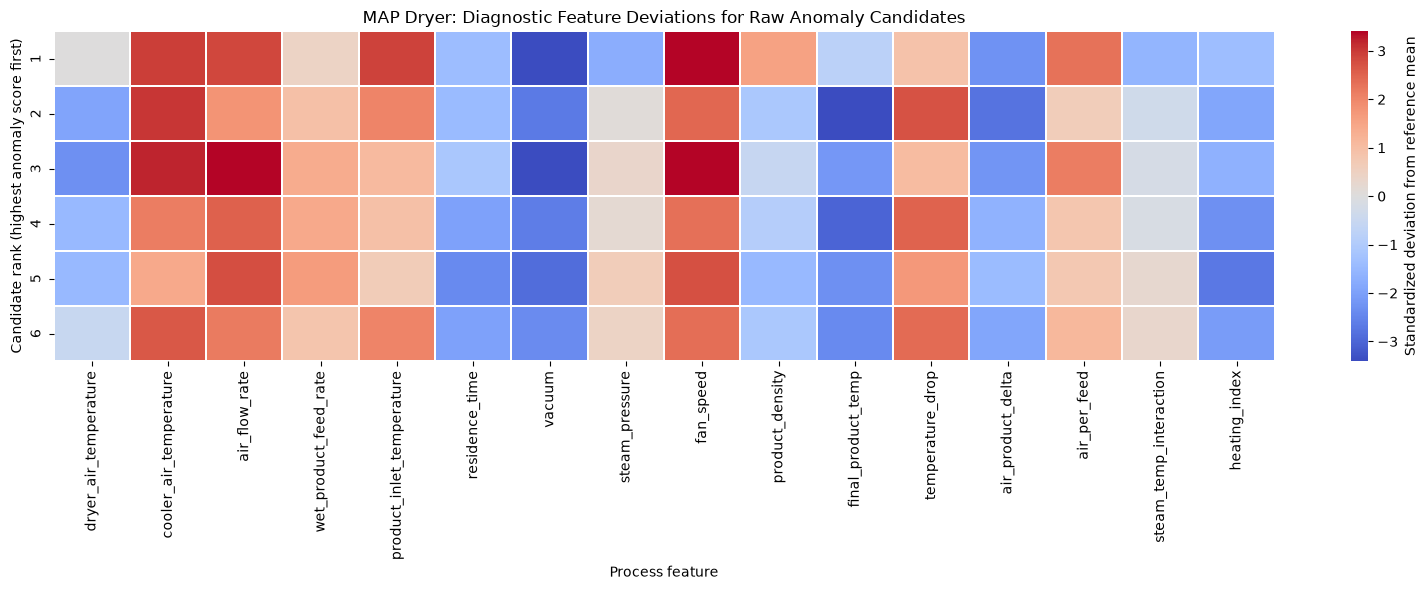

In [17]:
def build_scaled_feature_table(split_name, timestamps, scaled_features):
    split_table = scaled_features[MODEL_FEATURES].reset_index(drop=True).copy()
    split_table.insert(0, "Split", split_name)
    split_table.insert(0, "timestamp", timestamps.to_numpy())
    return split_table


scaled_feature_timeline = (
    pd.concat(
        [
            build_scaled_feature_table(
                "Reference", train_timestamps, X_train_scaled
            ),
            build_scaled_feature_table(
                "Validation", validation_timestamps, X_validation_scaled
            ),
            build_scaled_feature_table(
                "Testing", test_timestamps, X_test_scaled
            ),
        ],
        ignore_index=True,
    )
    .sort_values("timestamp", kind="stable")
    .reset_index(drop=True)
)

candidate_scaled_features = (
    anomalous_operating_points[
        ["Candidate rank", "timestamp", "Split", "Anomaly score"]
    ]
    .merge(
        scaled_feature_timeline[["timestamp", *MODEL_FEATURES]],
        on="timestamp",
        how="left",
        validate="one_to_one",
    )
    .sort_values("Candidate rank")
    .reset_index(drop=True)
)

diagnostic_records = []
for _, candidate in candidate_scaled_features.iterrows():
    ordered_features = (
        candidate[MODEL_FEATURES].astype(float).abs().sort_values(ascending=False)
    )
    for contributor_rank, feature in enumerate(ordered_features.index[:3], start=1):
        signed_deviation = float(candidate[feature])
        diagnostic_records.append(
            {
                "Candidate rank": int(candidate["Candidate rank"]),
                "timestamp": candidate["timestamp"],
                "Split": candidate["Split"],
                "Anomaly score": candidate["Anomaly score"],
                "Contributor rank": contributor_rank,
                "Feature": feature,
                "Signed standardized deviation": signed_deviation,
                "Absolute standardized deviation": abs(signed_deviation),
            }
        )

contributing_variable_diagnostics = pd.DataFrame(diagnostic_records)
contributor_summary = (
    contributing_variable_diagnostics.groupby("Feature")
    .agg(
        Top_three_appearances=("Feature", "size"),
        Mean_absolute_deviation=("Absolute standardized deviation", "mean"),
        Maximum_absolute_deviation=("Absolute standardized deviation", "max"),
    )
    .sort_values(
        ["Top_three_appearances", "Mean_absolute_deviation"],
        ascending=False,
    )
)

diagnostic_rounding = {
    "Anomaly score": 4,
    "Signed standardized deviation": 4,
    "Absolute standardized deviation": 4,
}
display(contributing_variable_diagnostics.round(diagnostic_rounding))
display(contributor_summary.round(4))

candidate_heatmap = candidate_scaled_features.set_index("Candidate rank")[
    MODEL_FEATURES
]
heatmap_limit = max(3.0, float(np.nanpercentile(np.abs(candidate_heatmap), 95)))
plt.figure(figsize=(16, max(6, 0.45 * len(candidate_heatmap))))
sns.heatmap(
    candidate_heatmap,
    cmap="coolwarm",
    center=0,
    vmin=-heatmap_limit,
    vmax=heatmap_limit,
    linewidths=0.2,
    cbar_kws={"label": "Standardized deviation from reference mean"},
)
plt.title("MAP Dryer: Diagnostic Feature Deviations for Raw Anomaly Candidates")
plt.xlabel("Process feature")
plt.ylabel("Candidate rank (highest anomaly score first)")
plt.tight_layout()
plt.savefig(
    FIGURE_OUTPUT_DIR / "03_candidate_feature_deviation_heatmap.png",
    dpi=300,
    bbox_inches="tight",
)
plt.show()

## 15. Add persistence and alarm logic

Reduce nuisance alarms by requiring at least two raw anomaly candidates within a rolling window of three observations. At the dataset's two-hour sampling interval, this evaluates the current observation and the preceding four hours. A persistent alarm remains active while the rolling condition is satisfied. Persistence state is reset at each artificial train/validation/test boundary so candidates from validation cannot leak into test evaluation; a deployed stream would carry its state continuously.

,Split,Alarm start,Alarm end,Alarm observations,Raw candidates while active,Maximum anomaly score
Alarm episode,,,,,,
1,Validation,2026-06-25 19:00:00,2026-06-25 21:00:00,2,1,0.62833
2,Testing,2026-07-10 15:00:00,2026-07-10 23:00:00,5,3,0.61633


,Observations
Combined alarm state,
Normal within configured PCS7 limits,927
Warning: PCS7 limit,122
Critical: PCS7 limit,23
Critical: PCS7 limit + persistent ML anomaly,3
High: PCS7 warning + persistent ML anomaly,3
Review: raw ML candidate,1
Advisory: persistent ML anomaly,1


Persistence rule: 2 of 3 observations; sample interval = 0 days 02:00:00.


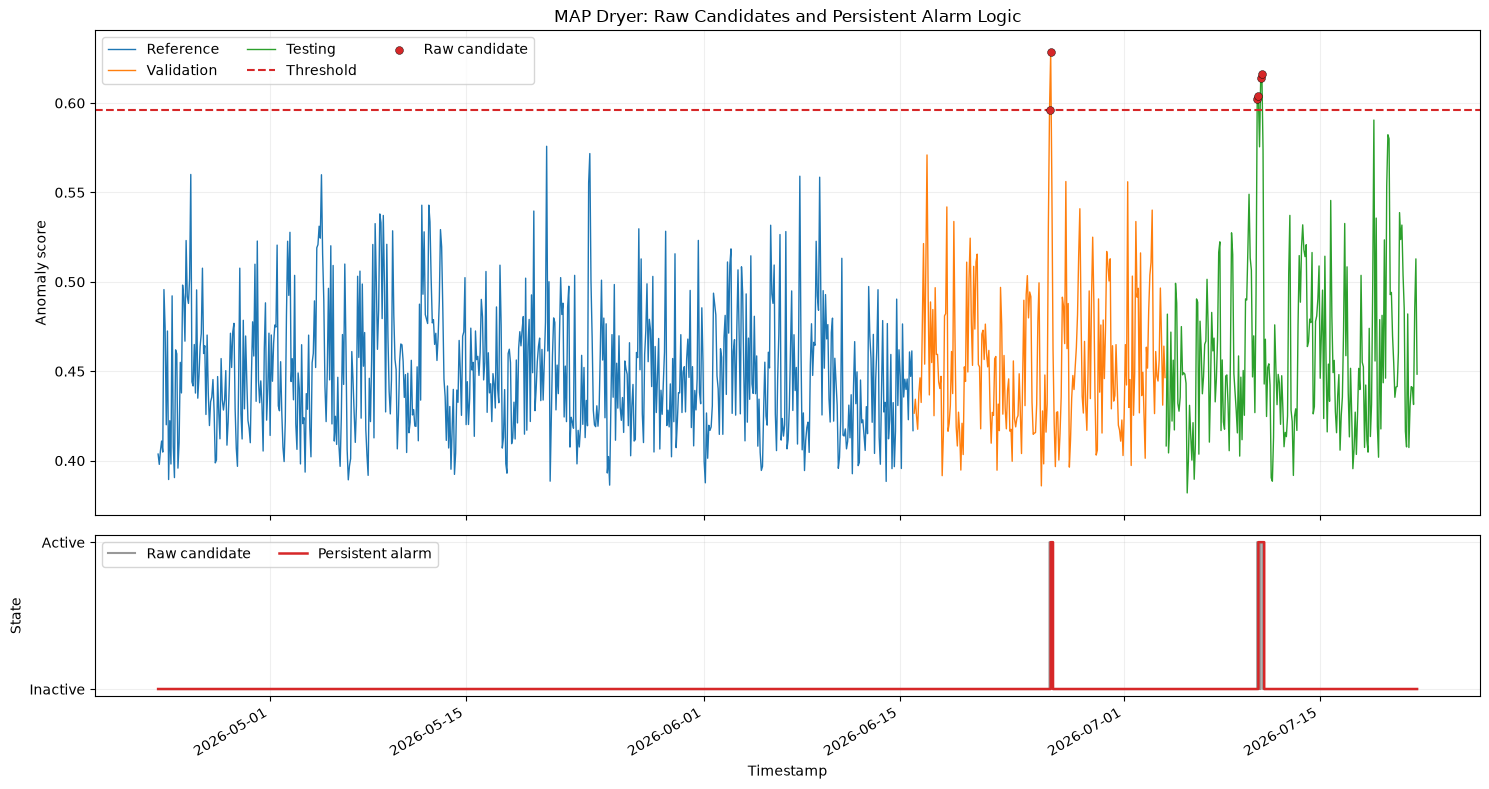

In [18]:
PERSISTENCE_WINDOW_OBSERVATIONS = 3
MINIMUM_CANDIDATES_IN_WINDOW = 2

observed_intervals = (
    anomaly_score_results["timestamp"].sort_values().diff().dropna()
)
EXPECTED_SAMPLE_INTERVAL = observed_intervals.mode().iloc[0]
CADENCE_GAP_TOLERANCE = 1.5
irregular_interval_count = int(
    (observed_intervals > EXPECTED_SAMPLE_INTERVAL * CADENCE_GAP_TOLERANCE).sum()
)
if irregular_interval_count:
    print(
        f"Detected {irregular_interval_count} sampling gaps; persistence state "
        "will reset at each gap."
    )


def apply_persistence_logic(
    score_table,
    window_observations=PERSISTENCE_WINDOW_OBSERVATIONS,
    minimum_candidates=MINIMUM_CANDIDATES_IN_WINDOW,
):
    alarm_table = score_table.sort_values("timestamp", kind="stable").copy()
    split_boundary = alarm_table["Split"].ne(alarm_table["Split"].shift())
    cadence_gap = alarm_table["timestamp"].diff().gt(
        EXPECTED_SAMPLE_INTERVAL * CADENCE_GAP_TOLERANCE
    )
    alarm_table["Cadence segment"] = (split_boundary | cadence_gap).cumsum()
    alarm_table["Candidates in persistence window"] = (
        alarm_table.groupby(["Split", "Cadence segment"], sort=False)["Raw anomaly flag"]
        .transform(
            lambda flags: flags.astype(int)
            .rolling(window=window_observations, min_periods=1)
            .sum()
        )
        .astype(int)
    )
    alarm_table["Persistent alarm"] = (
        alarm_table["Candidates in persistence window"] >= minimum_candidates
    )
    previous_alarm_state = alarm_table.groupby(
        ["Split", "Cadence segment"], sort=False
    )["Persistent alarm"].shift(fill_value=False)
    alarm_starts = alarm_table["Persistent alarm"] & ~previous_alarm_state
    alarm_numbers = alarm_starts.cumsum()
    alarm_table["Alarm episode"] = alarm_numbers.where(
        alarm_table["Persistent alarm"]
    ).astype("Int64")
    return alarm_table.reset_index(drop=True)


anomaly_score_results = apply_persistence_logic(anomaly_score_results)


def attach_pcs7_hybrid_alarm_state(score_table):
    pcs7_columns = [
        "timestamp",
        "PCS7 warning count",
        "PCS7 critical count",
        "PCS7 breach count",
        "PCS7 rule breach",
        "PCS7 breached features",
        "PCS7 limit status",
    ]
    hybrid_table = score_table.merge(
        pcs7_limit_results[pcs7_columns],
        on="timestamp",
        how="left",
        validate="one_to_one",
    )
    pcs7_critical = hybrid_table["PCS7 critical count"] > 0
    pcs7_warning = hybrid_table["PCS7 warning count"] > 0
    persistent_ml = hybrid_table["Persistent alarm"]
    raw_ml = hybrid_table["Raw anomaly flag"]

    default_state = (
        "No active alert (PCS7 limits not configured)"
        if CONFIGURED_PCS7_LIMIT_COUNT == 0
        else "Normal within configured PCS7 limits"
    )
    hybrid_table["Combined alarm state"] = np.select(
        [
            pcs7_critical & persistent_ml,
            pcs7_critical,
            pcs7_warning & persistent_ml,
            pcs7_warning,
            persistent_ml,
            raw_ml,
        ],
        [
            "Critical: PCS7 limit + persistent ML anomaly",
            "Critical: PCS7 limit",
            "High: PCS7 warning + persistent ML anomaly",
            "Warning: PCS7 limit",
            "Advisory: persistent ML anomaly",
            "Review: raw ML candidate",
        ],
        default=default_state,
    )
    hybrid_table["Combined severity level"] = np.select(
        [
            pcs7_critical & persistent_ml,
            pcs7_critical,
            pcs7_warning & persistent_ml,
            pcs7_warning,
            persistent_ml,
            raw_ml,
        ],
        [5, 5, 4, 3, 2, 1],
        default=0,
    ).astype(int)
    return hybrid_table.sort_values("timestamp", kind="stable").reset_index(drop=True)


anomaly_score_results = attach_pcs7_hybrid_alarm_state(anomaly_score_results)

persistent_alarm_rows = anomaly_score_results.loc[
    anomaly_score_results["Persistent alarm"]
]
if persistent_alarm_rows.empty:
    alarm_event_summary = pd.DataFrame(
        columns=[
            "Split",
            "Alarm start",
            "Alarm end",
            "Alarm observations",
            "Raw candidates while active",
            "Maximum anomaly score",
        ]
    )
else:
    alarm_event_summary = persistent_alarm_rows.groupby("Alarm episode").agg(
        Split=("Split", lambda values: " / ".join(pd.unique(values))),
        Alarm_start=("timestamp", "min"),
        Alarm_end=("timestamp", "max"),
        Alarm_observations=("Persistent alarm", "size"),
        Raw_candidates_while_active=("Raw anomaly flag", "sum"),
        Maximum_anomaly_score=("Anomaly score", "max"),
    )
    alarm_event_summary.columns = [
        "Split",
        "Alarm start",
        "Alarm end",
        "Alarm observations",
        "Raw candidates while active",
        "Maximum anomaly score",
    ]

hybrid_state_summary = (
    anomaly_score_results["Combined alarm state"]
    .value_counts()
    .rename_axis("Combined alarm state")
    .to_frame("Observations")
)
display(alarm_event_summary.round({"Maximum anomaly score": 5}))
display(hybrid_state_summary)
print(
    f"Persistence rule: {MINIMUM_CANDIDATES_IN_WINDOW} of "
    f"{PERSISTENCE_WINDOW_OBSERVATIONS} observations; "
    f"sample interval = {EXPECTED_SAMPLE_INTERVAL}."
)

fig, axes = plt.subplots(
    2, 1, figsize=(15, 8), sharex=True, gridspec_kw={"height_ratios": [3, 1]}
)
for split_name, split_color in split_colors.items():
    split_scores = anomaly_score_results.loc[
        anomaly_score_results["Split"] == split_name
    ]
    axes[0].plot(
        split_scores["timestamp"],
        split_scores["Anomaly score"],
        color=split_color,
        linewidth=1,
        label=split_name,
    )
axes[0].axhline(ANOMALY_THRESHOLD, color="tab:red", linestyle="--", label="Threshold")
axes[0].scatter(
    raw_anomaly_candidates["timestamp"],
    raw_anomaly_candidates["Anomaly score"],
    color="tab:red",
    edgecolor="black",
    linewidth=0.3,
    s=32,
    zorder=4,
    label="Raw candidate",
)
axes[0].set_ylabel("Anomaly score")
axes[0].set_title("MAP Dryer: Raw Candidates and Persistent Alarm Logic")
axes[0].grid(alpha=0.2)
axes[0].legend(loc="upper left", ncol=3)

axes[1].step(
    anomaly_score_results["timestamp"],
    anomaly_score_results["Raw anomaly flag"].astype(int),
    where="post",
    color="grey",
    alpha=0.8,
    label="Raw candidate",
)
axes[1].step(
    anomaly_score_results["timestamp"],
    anomaly_score_results["Persistent alarm"].astype(int),
    where="post",
    color="tab:red",
    linewidth=1.8,
    label="Persistent alarm",
)
axes[1].set_yticks([0, 1], labels=["Inactive", "Active"])
axes[1].set_ylabel("State")
axes[1].set_xlabel("Timestamp")
axes[1].grid(alpha=0.2)
axes[1].legend(loc="upper left", ncol=2)
fig.autofmt_xdate()
fig.tight_layout()
fig.savefig(
    FIGURE_OUTPUT_DIR / "04_persistent_alarm_logic.png",
    dpi=300,
    bbox_inches="tight",
)
plt.show()

### Hybrid PCS7 and machine-learning alarm timeline

Keep deterministic PCS7 rule status separate from the statistical ML signal, then combine them into a prioritized state. Critical PCS7 violations have the highest priority, followed by simultaneous PCS7 warnings and persistent ML anomalies, standalone PCS7 warnings, persistent ML advisories, and isolated raw ML candidates. Until limits are configured, the PCS7 component remains visibly disabled rather than silently treating observations as in-limit.

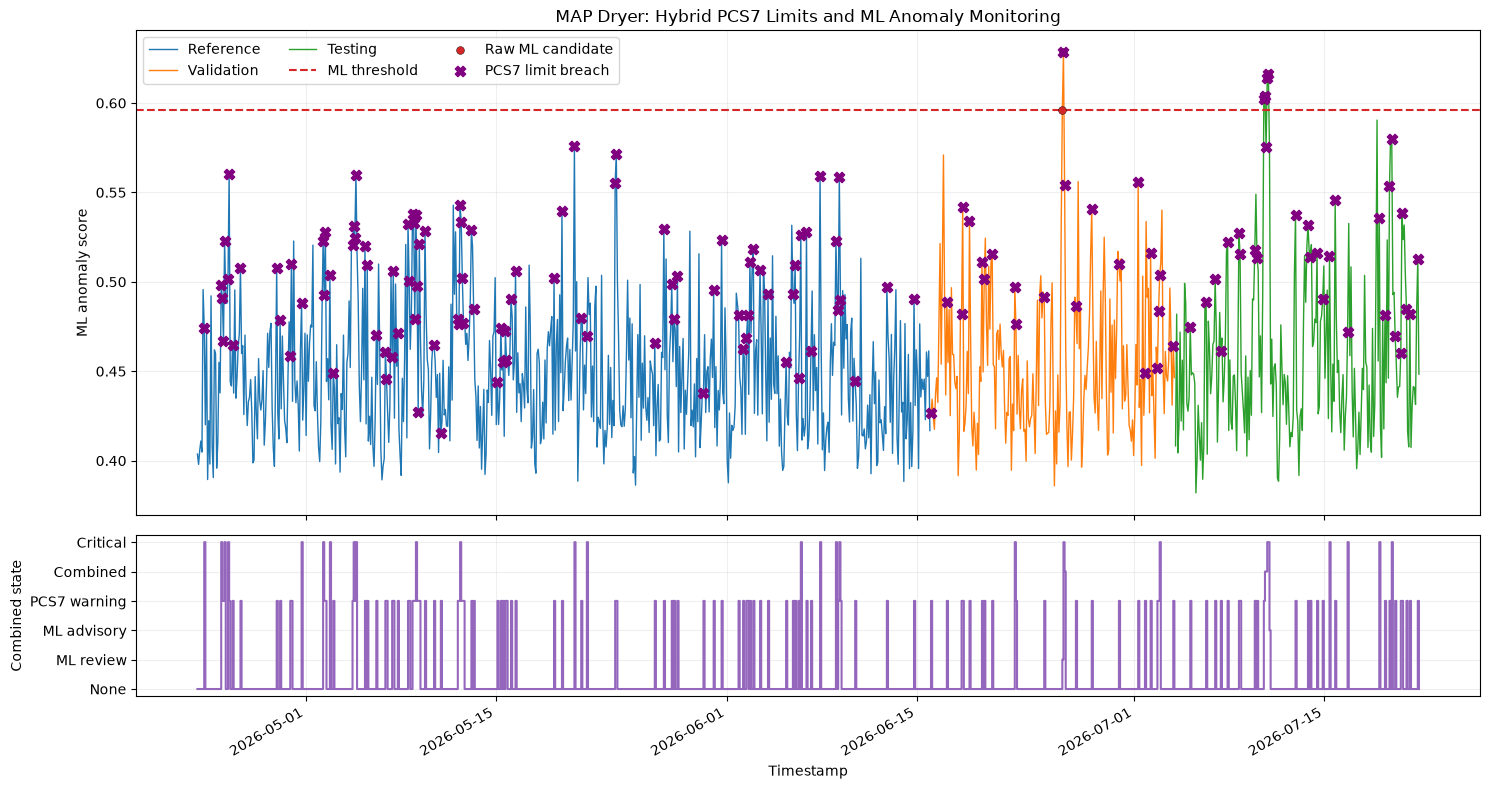

In [19]:
pcs7_breach_points = anomaly_score_results.loc[
    anomaly_score_results["PCS7 rule breach"]
]

fig, axes = plt.subplots(
    2, 1, figsize=(15, 8), sharex=True, gridspec_kw={"height_ratios": [3, 1]}
)
for split_name, split_color in split_colors.items():
    split_scores = anomaly_score_results.loc[
        anomaly_score_results["Split"] == split_name
    ]
    axes[0].plot(
        split_scores["timestamp"],
        split_scores["Anomaly score"],
        color=split_color,
        linewidth=1,
        label=split_name,
    )
axes[0].axhline(
    ANOMALY_THRESHOLD,
    color="tab:red",
    linestyle="--",
    label="ML threshold",
)
axes[0].scatter(
    raw_anomaly_candidates["timestamp"],
    raw_anomaly_candidates["Anomaly score"],
    color="tab:red",
    edgecolor="black",
    linewidth=0.3,
    s=32,
    zorder=4,
    label="Raw ML candidate",
)
if not pcs7_breach_points.empty:
    axes[0].scatter(
        pcs7_breach_points["timestamp"],
        pcs7_breach_points["Anomaly score"],
        color="purple",
        marker="X",
        s=55,
        zorder=5,
        label="PCS7 limit breach",
    )
axes[0].set_title("MAP Dryer: Hybrid PCS7 Limits and ML Anomaly Monitoring")
axes[0].set_ylabel("ML anomaly score")
axes[0].grid(alpha=0.2)
axes[0].legend(loc="upper left", ncol=3)

axes[1].step(
    anomaly_score_results["timestamp"],
    anomaly_score_results["Combined severity level"],
    where="post",
    color="tab:purple",
    linewidth=1.5,
)
axes[1].set_yticks(
    [0, 1, 2, 3, 4, 5],
    labels=["None", "ML review", "ML advisory", "PCS7 warning", "Combined", "Critical"],
)
axes[1].set_ylabel("Combined state")
axes[1].set_xlabel("Timestamp")
axes[1].grid(alpha=0.2)
fig.autofmt_xdate()
fig.tight_layout()
fig.savefig(
    FIGURE_OUTPUT_DIR / "05_hybrid_pcs7_ml_alarm_timeline.png",
    dpi=300,
    bbox_inches="tight",
)
plt.show()

if CONFIGURED_PCS7_LIMIT_COUNT == 0:
    print(
        "Hybrid timeline prepared: PCS7 breach markers remain disabled until limits are configured."
    )

## 16. Evaluate the model

Confirmed anomaly labels are not available, so supervised metrics such as precision, recall, and ROC AUC cannot be reported honestly. Evaluate the baseline detector using four complementary proxies: alert burden by chronological split, score drift, feature-level drift, and sensitivity to a suite of controlled synthetic deviations applied only to validation data. Synthetic faults modify direct measurements in original engineering units and then recompute all dependent engineered features, avoiding the physically inconsistent rows produced by independently shifting derived columns. These tests measure sensitivity, not real-world accuracy.

In [20]:
from scipy.stats import ks_2samp

split_evaluation = anomaly_score_results.groupby("Split", sort=False).agg(
    Observations=("Anomaly score", "size"),
    Median_score=("Anomaly score", "median"),
    Score_95th_percentile=("Anomaly score", lambda values: values.quantile(0.95)),
    Raw_candidates=("Raw anomaly flag", "sum"),
    Persistent_alarm_observations=("Persistent alarm", "sum"),
    Persistent_alarm_episodes=("Alarm episode", "nunique"),
)
split_evaluation["Raw candidate rate (%)"] = (
    100 * split_evaluation["Raw_candidates"] / split_evaluation["Observations"]
)
split_evaluation["Persistent alarm rate (%)"] = (
    100
    * split_evaluation["Persistent_alarm_observations"]
    / split_evaluation["Observations"]
)

reference_score_values = anomaly_score_results.loc[
    anomaly_score_results["Split"] == "Reference", "Anomaly score"
]
score_drift_rows = []
for later_split in ["Validation", "Testing"]:
    later_scores = anomaly_score_results.loc[
        anomaly_score_results["Split"] == later_split, "Anomaly score"
    ]
    drift_test = ks_2samp(reference_score_values, later_scores)
    score_drift_rows.append(
        {
            "Comparison": f"Reference vs {later_split}",
            "KS statistic": drift_test.statistic,
            "p-value": drift_test.pvalue,
            "Median score change": (
                later_scores.median() - reference_score_values.median()
            ),
        }
    )
score_drift_evaluation = pd.DataFrame(score_drift_rows).set_index("Comparison")

feature_drift_rows = []
for feature in MODEL_FEATURES:
    reference_values = X_normal_reference[feature]
    reference_scale = max(float(reference_values.std(ddof=0)), 1e-12)
    validation_drift = ks_2samp(reference_values, X_validation[feature])
    test_drift = ks_2samp(reference_values, X_test[feature])
    feature_drift_rows.append(
        {
            "Feature": feature,
            "Validation KS statistic": validation_drift.statistic,
            "Validation median shift (reference SD)": (
                X_validation[feature].median() - reference_values.median()
            ) / reference_scale,
            "Test KS statistic - descriptive": test_drift.statistic,
            "Test median shift (reference SD) - descriptive": (
                X_test[feature].median() - reference_values.median()
            ) / reference_scale,
        }
    )
feature_drift_evaluation = (
    pd.DataFrame(feature_drift_rows)
    .set_index("Feature")
    .sort_values("Validation KS statistic", ascending=False)
)


def recompute_engineered_anomaly_features(direct_feature_data):
    synthetic_data = direct_feature_data.copy()
    synthetic_data["temperature_drop"] = (
        synthetic_data["dryer_air_temperature"]
        - synthetic_data["final_product_temp"]
    )
    synthetic_data["air_product_delta"] = (
        synthetic_data["dryer_air_temperature"]
        - synthetic_data["product_inlet_temperature"]
    )
    synthetic_data["air_per_feed"] = (
        synthetic_data["air_flow_rate"]
        / synthetic_data["wet_product_feed_rate"]
    )
    synthetic_data["steam_temp_interaction"] = (
        synthetic_data["steam_pressure"]
        * synthetic_data["dryer_air_temperature"]
    )
    synthetic_data["heating_index"] = (
        synthetic_data["residence_time"]
        * synthetic_data["dryer_air_temperature"]
    )
    return synthetic_data[MODEL_FEATURES]


def build_synthetic_validation_scenario(
    features_per_row, shift_standard_deviations, random_state
):
    synthetic_direct = X_validation[DIRECT_PROCESS_FEATURES].reset_index(
        drop=True
    ).copy()
    reference_center = X_normal_reference[DIRECT_PROCESS_FEATURES].median()
    reference_scale = X_normal_reference[DIRECT_PROCESS_FEATURES].std(ddof=0)
    if (reference_scale <= 0).any():
        raise ValueError("Synthetic testing requires variable reference features.")
    scenario_rng = np.random.default_rng(random_state)
    for row_position in range(len(synthetic_direct)):
        feature_positions = scenario_rng.choice(
            len(DIRECT_PROCESS_FEATURES),
            size=features_per_row,
            replace=False,
        )
        row_values = synthetic_direct.iloc[row_position, feature_positions].to_numpy()
        center_values = reference_center.iloc[feature_positions].to_numpy()
        outward_direction = np.where(row_values >= center_values, 1.0, -1.0)
        synthetic_direct.iloc[row_position, feature_positions] = (
            row_values
            + outward_direction
            * shift_standard_deviations
            * reference_scale.iloc[feature_positions].to_numpy()
        )
    synthetic_features = recompute_engineered_anomaly_features(synthetic_direct)
    return pd.DataFrame(
        anomaly_scaler.transform(synthetic_features),
        columns=MODEL_FEATURES,
        index=X_validation_scaled.index,
    )


SYNTHETIC_SCENARIO_SPECIFICATIONS = {
    "Single sensor bias (3 reference SD)": (1, 3.0, 55),
    "Single sensor bias (4 reference SD)": (1, 4.0, 60),
    "Two-variable excursion (2 reference SD)": (2, 2.0, 66),
    "Two-variable excursion (3 reference SD)": (2, 3.0, 68),
    "Three-variable excursion (2 reference SD)": (3, 2.0, 76),
    "Three-variable excursion (3 reference SD)": (3, 3.0, 78),
    "Three-variable excursion (4 reference SD)": (3, 4.0, 80),
}
synthetic_validation_scenarios_scaled = {
    scenario_name: build_synthetic_validation_scenario(*scenario_parameters)
    for scenario_name, scenario_parameters in SYNTHETIC_SCENARIO_SPECIFICATIONS.items()
}
baseline_synthetic_scenario_detection = pd.Series(
    {
        scenario_name: np.mean(
            -isolation_forest_model.score_samples(scenario_features)
            >= ANOMALY_THRESHOLD
        )
        for scenario_name, scenario_features in (
            synthetic_validation_scenarios_scaled.items()
        )
    },
    name="Baseline Isolation Forest detection rate",
)
baseline_synthetic_detection_rate = float(
    baseline_synthetic_scenario_detection.mean()
)

baseline_evaluation_summary = pd.Series(
    {
        "Validation raw candidate rate (%)": split_evaluation.loc[
            "Validation", "Raw candidate rate (%)"
        ],
        "Validation persistent alarm episodes": split_evaluation.loc[
            "Validation", "Persistent_alarm_episodes"
        ],
        "Mean synthetic scenario detection rate (%)": (
            100 * baseline_synthetic_detection_rate
        ),
        "Test raw candidate rate (%) - descriptive only": split_evaluation.loc[
            "Testing", "Raw candidate rate (%)"
        ],
        "Test persistent alarm episodes - descriptive only": split_evaluation.loc[
            "Testing", "Persistent_alarm_episodes"
        ],
    },
    name="Baseline Isolation Forest",
)

if CONFIGURED_PCS7_LIMIT_COUNT > 0:
    pcs7_breach_mask = anomaly_score_results["PCS7 rule breach"]
    pcs7_breach_count = int(pcs7_breach_mask.sum())
    pcs7_ml_agreement = pd.crosstab(
        anomaly_score_results["PCS7 limit status"],
        anomaly_score_results["Persistent alarm"],
        rownames=["PCS7 status"],
        colnames=["Persistent ML alarm"],
    )
    pcs7_ml_comparison = pd.Series(
        {
            "Configured PCS7 limit breaches": pcs7_breach_count,
            "PCS7 breaches also detected as raw ML candidates (%)": (
                100
                * anomaly_score_results.loc[pcs7_breach_mask, "Raw anomaly flag"].mean()
                if pcs7_breach_count
                else np.nan
            ),
            "PCS7 breaches also detected as persistent ML alarms (%)": (
                100
                * anomaly_score_results.loc[pcs7_breach_mask, "Persistent alarm"].mean()
                if pcs7_breach_count
                else np.nan
            ),
            "Raw ML candidates without a PCS7 breach": int(
                (
                    anomaly_score_results["Raw anomaly flag"]
                    & ~pcs7_breach_mask
                ).sum()
            ),
        },
        name="PCS7 and ML comparison",
    )
else:
    pcs7_ml_agreement = pd.DataFrame(
        {
            "Status": [
                "Unavailable until at least one approved PCS7 limit is configured."
            ]
        }
    )
    pcs7_ml_comparison = pd.Series(
        {"Configured PCS7 limits": 0},
        name="PCS7 and ML comparison",
    )

display(split_evaluation.round(4))
display(score_drift_evaluation.round(5))
display(feature_drift_evaluation.round(4))
display((100 * baseline_synthetic_scenario_detection).to_frame().round(2))
display(baseline_evaluation_summary.to_frame().round(4))
display(pcs7_ml_agreement)
display(pcs7_ml_comparison.to_frame().round(4))
print(
    "Evaluation is label-free: alert rates and synthetic sensitivity are proxies, "
    "not estimates of real anomaly-detection accuracy."
)

,Observations,Median_score,Score_95th_percentile,Raw_candidates,Persistent_alarm_observations,Persistent_alarm_episodes,Raw candidate rate (%),Persistent alarm rate (%)
Split,,,,,,,,
Reference,648,0.4452,0.5209,0,0,0,0.0000,0.0000
Validation,216,0.4478,0.5314,2,2,1,0.9259,0.9259
Testing,216,0.4486,0.5464,4,5,1,1.8519,2.3148


,KS statistic,p-value,Median score change
Comparison,,,
Reference vs Validation,0.07716,0.28265,0.00261
Reference vs Testing,0.10031,0.07417,0.00340


,Validation KS statistic,Validation median shift (reference SD),Test KS statistic - descriptive,Test median shift (reference SD) - descriptive
Feature,,,,
cooler_air_temperature,0.1991,0.5345,0.2793,0.8260
air_per_feed,0.1806,0.3757,0.2191,0.4784
residence_time,0.1497,0.2688,0.0972,-0.1867
final_product_temp,0.1466,-0.2867,0.1975,-0.4301
wet_product_feed_rate,0.1404,-0.3259,0.0664,0.0121
product_density,0.1281,-0.1896,0.0694,-0.1896
air_product_delta,0.1265,-0.2967,0.1806,-0.4316
temperature_drop,0.1219,0.2700,0.2238,0.4860
steam_pressure,0.1157,-0.2719,0.0571,0.0000


,Baseline Isolation Forest detection rate
Single sensor bias (3 reference SD),0.93
Single sensor bias (4 reference SD),2.78
Two-variable excursion (2 reference SD),2.78
Two-variable excursion (3 reference SD),4.63
Three-variable excursion (2 reference SD),9.72
Three-variable excursion (3 reference SD),19.44
Three-variable excursion (4 reference SD),25.00


,Baseline Isolation Forest
Validation raw candidate rate (%),0.9259
Validation persistent alarm episodes,1.0000
Mean synthetic scenario detection rate (%),9.3254
Test raw candidate rate (%) - descriptive only,1.8519
Test persistent alarm episodes - descriptive only,1.0000


Persistent ML alarm,False,True
PCS7 status,,
Critical,23,3
Warning,122,3
Within configured limits,928,1


,PCS7 and ML comparison
Configured PCS7 limit breaches,151.0000
PCS7 breaches also detected as raw ML candidates (%),3.3113
PCS7 breaches also detected as persistent ML alarms (%),3.9735
Raw ML candidates without a PCS7 breach,1.0000


Evaluation is label-free: alert rates and synthetic sensitivity are proxies, not estimates of real anomaly-detection accuracy.


## 17. Tune Isolation Forest hyperparameters

Tune the number of trees, samples per tree, and fraction of features per tree. Every candidate is fitted only on the normal reference period and calibrated with the same finite-sample validation rule. Rank configurations first by worst-case and then mean sensitivity across the physically consistent synthetic scenario suite, followed by lower reference candidate rate and score stability. This is more robust than optimizing one artificial disturbance. The test period is not used to select the configuration.

In [21]:
from itertools import product
from scipy.stats import spearmanr

ISOLATION_FOREST_TUNING_GRID = {
    "n_estimators": [200, 300, 500],
    "max_samples": sorted(
        {128, 256, min(512, len(X_normal_reference_scaled)), len(X_normal_reference_scaled)}
    ),
    "max_features": [0.50, 0.75, 1.0],
}

baseline_validation_score_values = anomaly_score_results.loc[
    anomaly_score_results["Split"] == "Validation", "Anomaly score"
].to_numpy()

tuning_rows = []
for n_estimators, max_samples, max_features in product(
    ISOLATION_FOREST_TUNING_GRID["n_estimators"],
    ISOLATION_FOREST_TUNING_GRID["max_samples"],
    ISOLATION_FOREST_TUNING_GRID["max_features"],
):
    candidate_model = IsolationForest(
        n_estimators=n_estimators,
        max_samples=max_samples,
        contamination="auto",
        max_features=max_features,
        bootstrap=False,
        random_state=42,
        n_jobs=-1,
    )
    candidate_model.fit(X_normal_reference_scaled)

    candidate_reference_scores = -candidate_model.score_samples(
        X_normal_reference_scaled
    )
    candidate_validation_scores = -candidate_model.score_samples(
        X_validation_scaled
    )
    candidate_threshold, _ = calibrate_conformal_threshold(
        candidate_validation_scores, TARGET_VALIDATION_CANDIDATE_RATE
    )
    candidate_synthetic_detection_rates = [
        np.mean(
            -candidate_model.score_samples(scenario_features)
            >= candidate_threshold
        )
        for scenario_features in synthetic_validation_scenarios_scaled.values()
    ]
    score_stability = spearmanr(
        baseline_validation_score_values, candidate_validation_scores
    ).statistic

    tuning_rows.append(
        {
            "n_estimators": n_estimators,
            "max_samples": max_samples,
            "max_features": max_features,
            "Validation threshold": candidate_threshold,
            "Reference candidate rate (%)": (
                100 * np.mean(candidate_reference_scores >= candidate_threshold)
            ),
            "Validation candidate rate (%)": (
                100 * np.mean(candidate_validation_scores >= candidate_threshold)
            ),
            "Worst synthetic detection rate (%)": (
                100 * np.min(candidate_synthetic_detection_rates)
            ),
            "Mean synthetic detection rate (%)": (
                100 * np.mean(candidate_synthetic_detection_rates)
            ),
            "Score stability vs baseline": score_stability,
        }
    )

tuning_results = (
    pd.DataFrame(tuning_rows)
    .sort_values(
        [
            "Worst synthetic detection rate (%)",
            "Mean synthetic detection rate (%)",
            "Reference candidate rate (%)",
            "Score stability vs baseline",
            "n_estimators",
        ],
        ascending=[False, False, True, False, True],
    )
    .reset_index(drop=True)
)

best_tuning_row = tuning_results.iloc[0]
best_isolation_forest_parameters = {
    "n_estimators": int(best_tuning_row["n_estimators"]),
    "max_samples": int(best_tuning_row["max_samples"]),
    "max_features": float(best_tuning_row["max_features"]),
}

selected_isolation_forest_model = IsolationForest(
    **best_isolation_forest_parameters,
    contamination="auto",
    bootstrap=False,
    random_state=42,
    n_jobs=-1,
)
selected_isolation_forest_model.fit(X_normal_reference_scaled)


def build_selected_score_table(split_name, timestamps, scaled_features):
    return pd.DataFrame(
        {
            "timestamp": timestamps.to_numpy(),
            "Split": split_name,
            "Anomaly score": -selected_isolation_forest_model.score_samples(
                scaled_features[MODEL_FEATURES]
            ),
        }
    )


selected_anomaly_score_results = (
    pd.concat(
        [
            build_selected_score_table(
                "Reference", train_timestamps, X_train_scaled
            ),
            build_selected_score_table(
                "Validation", validation_timestamps, X_validation_scaled
            ),
            build_selected_score_table(
                "Testing", test_timestamps, X_test_scaled
            ),
        ],
        ignore_index=True,
    )
    .sort_values("timestamp", kind="stable")
    .reset_index(drop=True)
)

selected_validation_scores = selected_anomaly_score_results.loc[
    selected_anomaly_score_results["Split"] == "Validation",
    "Anomaly score",
]
SELECTED_ANOMALY_THRESHOLD, SELECTED_THRESHOLD_ORDER_RANK = (
    calibrate_conformal_threshold(
        selected_validation_scores, TARGET_VALIDATION_CANDIDATE_RATE
    )
)
selected_anomaly_score_results["Raw anomaly flag"] = (
    selected_anomaly_score_results["Anomaly score"]
    >= SELECTED_ANOMALY_THRESHOLD
)
selected_anomaly_score_results = apply_persistence_logic(
    selected_anomaly_score_results
)
selected_anomaly_score_results = attach_pcs7_hybrid_alarm_state(
    selected_anomaly_score_results
)

selected_isolation_forest_synthetic_detection = pd.Series(
    {
        scenario_name: np.mean(
            -selected_isolation_forest_model.score_samples(scenario_features)
            >= SELECTED_ANOMALY_THRESHOLD
        )
        for scenario_name, scenario_features in (
            synthetic_validation_scenarios_scaled.items()
        )
    },
    name="Selected Isolation Forest",
)
selected_synthetic_detection_rate = float(
    selected_isolation_forest_synthetic_detection.mean()
)

def candidate_rate(score_table, split_name):
    split_rows = score_table.loc[score_table["Split"] == split_name]
    return 100 * split_rows["Raw anomaly flag"].mean()


baseline_vs_selected_comparison = pd.DataFrame(
    {
        "Baseline Isolation Forest": {
            "Trees": isolation_forest_model.n_estimators,
            "Maximum samples": isolation_forest_model.max_samples_,
            "Maximum feature fraction": isolation_forest_model.max_features,
            "Validation threshold": ANOMALY_THRESHOLD,
            "Reference candidate rate (%)": candidate_rate(
                anomaly_score_results, "Reference"
            ),
            "Validation candidate rate (%)": candidate_rate(
                anomaly_score_results, "Validation"
            ),
            "Mean synthetic detection rate (%)": (
                100 * baseline_synthetic_detection_rate
            ),
        },
        "Selected Isolation Forest": {
            "Trees": selected_isolation_forest_model.n_estimators,
            "Maximum samples": selected_isolation_forest_model.max_samples_,
            "Maximum feature fraction": selected_isolation_forest_model.max_features,
            "Validation threshold": SELECTED_ANOMALY_THRESHOLD,
            "Reference candidate rate (%)": candidate_rate(
                selected_anomaly_score_results, "Reference"
            ),
            "Validation candidate rate (%)": candidate_rate(
                selected_anomaly_score_results, "Validation"
            ),
            "Mean synthetic detection rate (%)": (
                100 * selected_synthetic_detection_rate
            ),
        },
    }
)

display(tuning_results.round(5))
display(baseline_vs_selected_comparison.round(5))
display((100 * selected_isolation_forest_synthetic_detection).to_frame().round(2))
print("Selected parameters:", best_isolation_forest_parameters)
print(f"Selected validation threshold: {SELECTED_ANOMALY_THRESHOLD:.5f}")
print("The test period was not used to rank or select hyperparameters.")

,n_estimators,max_samples,max_features,Validation threshold,Reference candidate rate (%),Validation candidate rate (%),Worst synthetic detection rate (%),Mean synthetic detection rate (%),Score stability vs baseline
0,200,128,0.75,0.57647,0.46296,0.92593,3.24074,16.13757,0.96673
1,300,128,0.75,0.58339,0.15432,0.92593,3.24074,12.63228,0.97347
2,200,512,0.75,0.57628,0.15432,0.92593,2.77778,22.61905,0.97364
3,500,512,1.00,0.58047,0.15432,0.92593,2.31481,19.24603,0.98537
4,200,648,0.50,0.58484,0.15432,0.92593,1.85185,21.36243,0.96864
5,300,648,0.75,0.58374,0.00000,0.92593,1.85185,20.43651,0.97766
6,300,512,1.00,0.58897,0.00000,0.92593,1.85185,14.81481,0.98224
7,300,256,0.75,0.58375,0.00000,0.92593,1.85185,14.35185,0.98043
8,500,256,0.75,0.58567,0.00000,0.92593,1.85185,13.75661,0.98148
9,500,648,0.75,0.58083,0.00000,0.92593,1.38889,22.68519,0.98188


,Baseline Isolation Forest,Selected Isolation Forest
Trees,300.00000,200.00000
Maximum samples,256.00000,128.00000
Maximum feature fraction,1.00000,0.75000
Validation threshold,0.59630,0.57647
Reference candidate rate (%),0.00000,0.46296
Validation candidate rate (%),0.92593,0.92593
Mean synthetic detection rate (%),9.32540,16.13757


,Selected Isolation Forest
Single sensor bias (3 reference SD),3.24
Single sensor bias (4 reference SD),4.17
Two-variable excursion (2 reference SD),5.56
Two-variable excursion (3 reference SD),11.57
Three-variable excursion (2 reference SD),19.44
Three-variable excursion (3 reference SD),30.56
Three-variable excursion (4 reference SD),38.43


Selected parameters: {'n_estimators': 200, 'max_samples': 128, 'max_features': 0.75}
Selected validation threshold: 0.57647
The test period was not used to rank or select hyperparameters.


## 18. Compare with another detector

Compare the selected Isolation Forest with a validation-tuned RBF One-Class SVM. Both detectors use the same normal reference, conformal calibration, physical synthetic scenario suite, and persistence rule. Choose a **provisional primary detector** using only validation proxy evidence; the untouched test period remains descriptive and confirmed event labels are still required before production approval.

,gamma,nu,Validation threshold,Reference candidate rate (%),Worst synthetic detection rate (%),Mean synthetic detection rate (%)
0,scale,0.020,-0.63416,0.00000,62.96296,87.30159
1,scale,0.005,-0.15845,0.00000,62.96296,87.23545
2,scale,0.010,-0.31702,0.00000,62.96296,87.23545
3,scale,0.050,-1.59769,0.00000,62.03704,86.83862
4,0.1,0.010,-0.10483,0.00000,59.25926,86.37566
5,0.1,0.020,-0.20946,0.00000,59.25926,86.37566
6,0.1,0.050,-0.52373,0.00000,59.25926,86.30952
7,0.05,0.005,-0.23412,0.00000,59.25926,85.18519
8,0.05,0.010,-0.46787,0.00000,59.25926,85.18519
9,0.05,0.020,-0.93599,0.00000,59.25926,85.18519


,Validation threshold,Reference candidate rate (%),Validation candidate rate (%),Validation persistent episodes,Worst synthetic detection rate (%),Mean synthetic detection rate (%),Test candidate rate (%) - descriptive,Test persistent episodes - descriptive
Detector,,,,,,,,
Selected Isolation Forest,0.57647,0.46296,0.92593,1,3.24074,16.13757,2.77778,1
Tuned One-Class SVM,-0.63416,0.00000,0.92593,0,62.96296,87.30159,2.31481,1


,Selected Isolation Forest,Tuned One-Class SVM
Single sensor bias (3 reference SD),3.24,62.96
Single sensor bias (4 reference SD),4.17,94.44
Two-variable excursion (2 reference SD),5.56,64.35
Two-variable excursion (3 reference SD),11.57,98.61
Three-variable excursion (2 reference SD),19.44,90.74
Three-variable excursion (3 reference SD),30.56,100.00
Three-variable excursion (4 reference SD),38.43,100.00


Agreement category,Both detectors,Isolation Forest only,Neither detector,One-Class SVM only
Split,,,,
Reference,0,3,645,0
Testing,2,4,207,3
Validation,1,1,213,1


Validation score-rank correlation: 0.898
Selected One-Class SVM parameters: {'gamma': 'scale', 'nu': 0.02}
Provisional primary detector: Tuned One-Class SVM
Selection uses validation proxy evidence only; real labeled events are required before production approval.


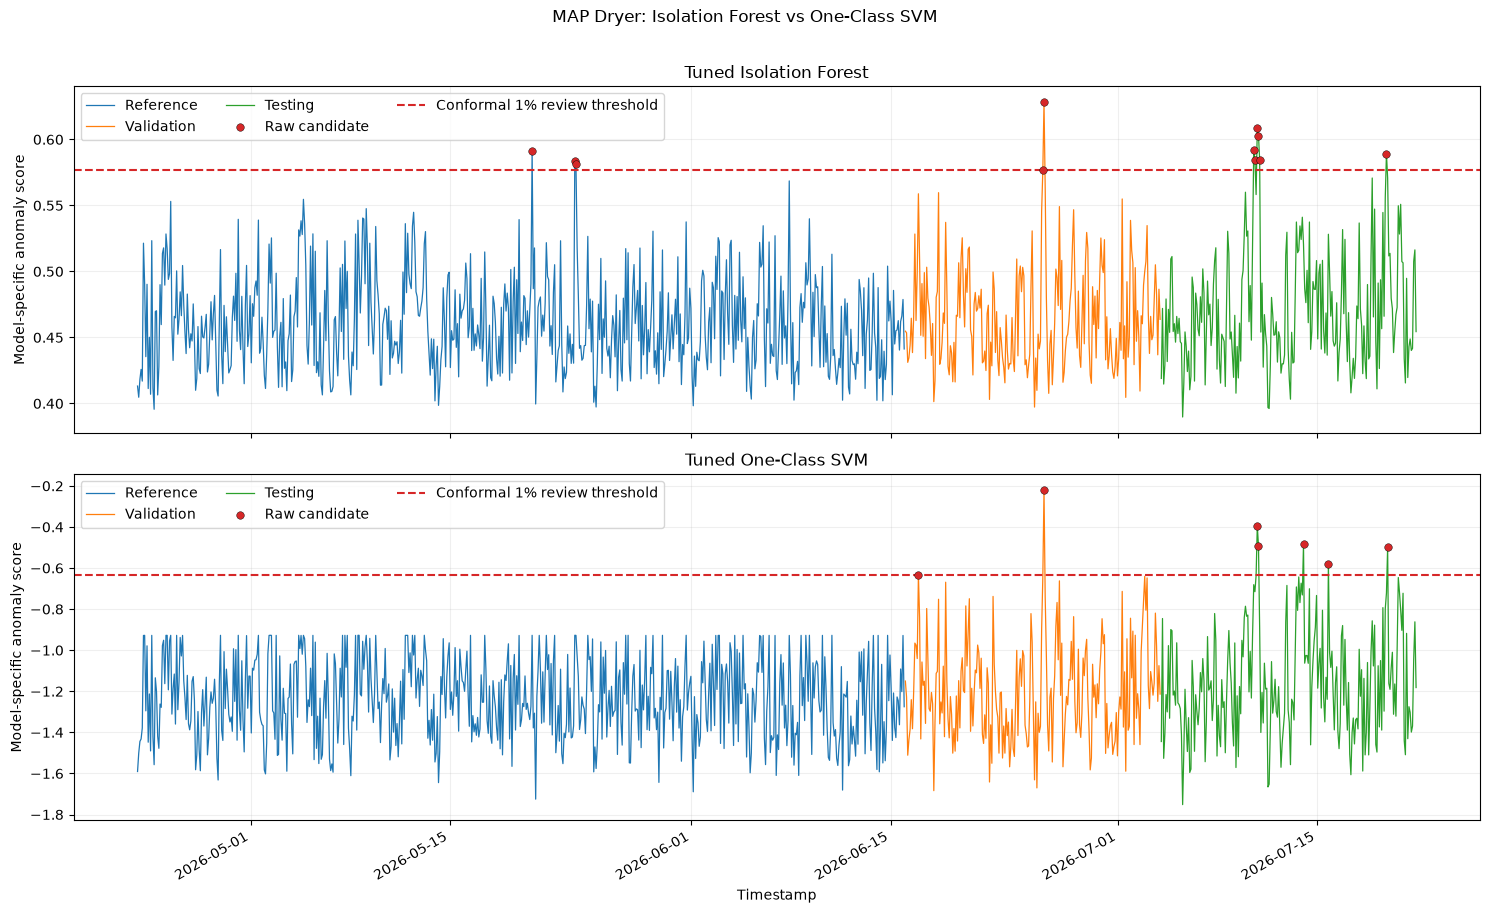

In [22]:
from sklearn.svm import OneClassSVM

ONE_CLASS_SVM_TUNING_GRID = {
    "gamma": ["scale", 0.03, 0.05, 0.10],
    "nu": [0.005, 0.01, 0.02, 0.05],
}
one_class_svm_tuning_rows = []
for gamma_value, nu_value in product(
    ONE_CLASS_SVM_TUNING_GRID["gamma"],
    ONE_CLASS_SVM_TUNING_GRID["nu"],
):
    candidate_svm = OneClassSVM(
        kernel="rbf", gamma=gamma_value, nu=nu_value
    ).fit(X_normal_reference_scaled)
    candidate_reference_scores = -candidate_svm.score_samples(
        X_normal_reference_scaled
    )
    candidate_validation_scores = -candidate_svm.score_samples(
        X_validation_scaled
    )
    candidate_threshold, _ = calibrate_conformal_threshold(
        candidate_validation_scores, TARGET_VALIDATION_CANDIDATE_RATE
    )
    scenario_detection_rates = [
        np.mean(
            -candidate_svm.score_samples(scenario_features)
            >= candidate_threshold
        )
        for scenario_features in synthetic_validation_scenarios_scaled.values()
    ]
    one_class_svm_tuning_rows.append(
        {
            "gamma": gamma_value,
            "nu": nu_value,
            "Validation threshold": candidate_threshold,
            "Reference candidate rate (%)": 100 * np.mean(
                candidate_reference_scores >= candidate_threshold
            ),
            "Worst synthetic detection rate (%)": 100 * np.min(
                scenario_detection_rates
            ),
            "Mean synthetic detection rate (%)": 100 * np.mean(
                scenario_detection_rates
            ),
        }
    )

one_class_svm_tuning_results = (
    pd.DataFrame(one_class_svm_tuning_rows)
    .sort_values(
        [
            "Worst synthetic detection rate (%)",
            "Mean synthetic detection rate (%)",
            "Reference candidate rate (%)",
            "nu",
        ],
        ascending=[False, False, True, True],
    )
    .reset_index(drop=True)
)
best_svm_tuning_row = one_class_svm_tuning_results.iloc[0]
best_one_class_svm_parameters = {
    "gamma": best_svm_tuning_row["gamma"],
    "nu": float(best_svm_tuning_row["nu"]),
}
one_class_svm_model = OneClassSVM(
    kernel="rbf", **best_one_class_svm_parameters
)
one_class_svm_model.fit(X_normal_reference_scaled)


def build_one_class_svm_score_table(split_name, timestamps, scaled_features):
    return pd.DataFrame(
        {
            "timestamp": timestamps.to_numpy(),
            "Split": split_name,
            "Anomaly score": -one_class_svm_model.score_samples(
                scaled_features[MODEL_FEATURES]
            ),
        }
    )


one_class_svm_score_results = (
    pd.concat(
        [
            build_one_class_svm_score_table(
                "Reference", train_timestamps, X_train_scaled
            ),
            build_one_class_svm_score_table(
                "Validation", validation_timestamps, X_validation_scaled
            ),
            build_one_class_svm_score_table(
                "Testing", test_timestamps, X_test_scaled
            ),
        ],
        ignore_index=True,
    )
    .sort_values("timestamp", kind="stable")
    .reset_index(drop=True)
)

one_class_svm_validation_scores = one_class_svm_score_results.loc[
    one_class_svm_score_results["Split"] == "Validation",
    "Anomaly score",
]
ONE_CLASS_SVM_THRESHOLD, ONE_CLASS_SVM_THRESHOLD_ORDER_RANK = (
    calibrate_conformal_threshold(
        one_class_svm_validation_scores, TARGET_VALIDATION_CANDIDATE_RATE
    )
)
one_class_svm_score_results["Raw anomaly flag"] = (
    one_class_svm_score_results["Anomaly score"] >= ONE_CLASS_SVM_THRESHOLD
)
one_class_svm_score_results = apply_persistence_logic(
    one_class_svm_score_results
)
one_class_svm_score_results = attach_pcs7_hybrid_alarm_state(
    one_class_svm_score_results
)

one_class_svm_synthetic_detection = pd.Series(
    {
        scenario_name: np.mean(
            -one_class_svm_model.score_samples(scenario_features)
            >= ONE_CLASS_SVM_THRESHOLD
        )
        for scenario_name, scenario_features in (
            synthetic_validation_scenarios_scaled.items()
        )
    },
    name="Tuned One-Class SVM",
)
one_class_svm_synthetic_detection_rate = float(
    one_class_svm_synthetic_detection.mean()
)
synthetic_detector_comparison = 100 * pd.concat(
    [
        selected_isolation_forest_synthetic_detection,
        one_class_svm_synthetic_detection,
    ],
    axis=1,
)


def detector_comparison_row(
    detector_name, score_table, threshold, synthetic_detection_rates
):
    split_tables = {
        split_name: score_table.loc[score_table["Split"] == split_name]
        for split_name in ["Reference", "Validation", "Testing"]
    }
    return {
        "Detector": detector_name,
        "Validation threshold": threshold,
        "Reference candidate rate (%)": (
            100 * split_tables["Reference"]["Raw anomaly flag"].mean()
        ),
        "Validation candidate rate (%)": (
            100 * split_tables["Validation"]["Raw anomaly flag"].mean()
        ),
        "Validation persistent episodes": split_tables["Validation"][
            "Alarm episode"
        ].nunique(),
        "Worst synthetic detection rate (%)": (
            100 * synthetic_detection_rates.min()
        ),
        "Mean synthetic detection rate (%)": (
            100 * synthetic_detection_rates.mean()
        ),
        "Test candidate rate (%) - descriptive": (
            100 * split_tables["Testing"]["Raw anomaly flag"].mean()
        ),
        "Test persistent episodes - descriptive": split_tables["Testing"][
            "Alarm episode"
        ].nunique(),
    }


detector_comparison = pd.DataFrame(
    [
        detector_comparison_row(
            "Selected Isolation Forest",
            selected_anomaly_score_results,
            SELECTED_ANOMALY_THRESHOLD,
            selected_isolation_forest_synthetic_detection,
        ),
        detector_comparison_row(
            "Tuned One-Class SVM",
            one_class_svm_score_results,
            ONE_CLASS_SVM_THRESHOLD,
            one_class_svm_synthetic_detection,
        ),
    ]
).set_index("Detector")

detector_flag_agreement = (
    selected_anomaly_score_results[
        ["timestamp", "Split", "Raw anomaly flag"]
    ]
    .rename(columns={"Raw anomaly flag": "Isolation Forest flag"})
    .merge(
        one_class_svm_score_results[
            ["timestamp", "Raw anomaly flag"]
        ].rename(columns={"Raw anomaly flag": "One-Class SVM flag"}),
        on="timestamp",
        how="inner",
        validate="one_to_one",
    )
)
detector_flag_agreement["Agreement category"] = np.select(
    [
        detector_flag_agreement["Isolation Forest flag"]
        & detector_flag_agreement["One-Class SVM flag"],
        detector_flag_agreement["Isolation Forest flag"],
        detector_flag_agreement["One-Class SVM flag"],
    ],
    ["Both detectors", "Isolation Forest only", "One-Class SVM only"],
    default="Neither detector",
)
detector_agreement_summary = pd.crosstab(
    detector_flag_agreement["Split"],
    detector_flag_agreement["Agreement category"],
)

validation_score_comparison = (
    selected_anomaly_score_results.loc[
        selected_anomaly_score_results["Split"] == "Validation",
        ["timestamp", "Anomaly score"],
    ]
    .rename(columns={"Anomaly score": "Isolation Forest score"})
    .merge(
        one_class_svm_score_results.loc[
            one_class_svm_score_results["Split"] == "Validation",
            ["timestamp", "Anomaly score"],
        ].rename(columns={"Anomaly score": "One-Class SVM score"}),
        on="timestamp",
        validate="one_to_one",
    )
)
detector_validation_rank_correlation = spearmanr(
    validation_score_comparison["Isolation Forest score"],
    validation_score_comparison["One-Class SVM score"],
).statistic

provisional_detector_ranking = detector_comparison.sort_values(
    [
        "Worst synthetic detection rate (%)",
        "Mean synthetic detection rate (%)",
        "Reference candidate rate (%)",
    ],
    ascending=[False, False, True],
)
PROVISIONAL_SELECTED_DETECTOR = provisional_detector_ranking.index[0]
if PROVISIONAL_SELECTED_DETECTOR == "Tuned One-Class SVM":
    provisional_selected_model = one_class_svm_model
    PROVISIONAL_SELECTED_THRESHOLD = ONE_CLASS_SVM_THRESHOLD
    provisional_selected_score_results = one_class_svm_score_results.copy()
    provisional_selected_synthetic_detection = (
        one_class_svm_synthetic_detection.copy()
    )
else:
    provisional_selected_model = selected_isolation_forest_model
    PROVISIONAL_SELECTED_THRESHOLD = SELECTED_ANOMALY_THRESHOLD
    provisional_selected_score_results = selected_anomaly_score_results.copy()
    provisional_selected_synthetic_detection = (
        selected_isolation_forest_synthetic_detection.copy()
    )

display(one_class_svm_tuning_results.round(5))
display(detector_comparison.round(5))
display(synthetic_detector_comparison.round(2))
display(detector_agreement_summary)
print(
    f"Validation score-rank correlation: "
    f"{detector_validation_rank_correlation:.3f}"
)
print("Selected One-Class SVM parameters:", best_one_class_svm_parameters)
print("Provisional primary detector:", PROVISIONAL_SELECTED_DETECTOR)
print(
    "Selection uses validation proxy evidence only; real labeled events are "
    "required before production approval."
)

fig, axes = plt.subplots(2, 1, figsize=(15, 9), sharex=True)
detector_plot_settings = [
    (
        axes[0],
        selected_anomaly_score_results,
        SELECTED_ANOMALY_THRESHOLD,
        "Tuned Isolation Forest",
    ),
    (
        axes[1],
        one_class_svm_score_results,
        ONE_CLASS_SVM_THRESHOLD,
        "Tuned One-Class SVM",
    ),
]
for axis, score_table, threshold, detector_title in detector_plot_settings:
    for split_name, split_color in split_colors.items():
        split_scores = score_table.loc[score_table["Split"] == split_name]
        axis.plot(
            split_scores["timestamp"],
            split_scores["Anomaly score"],
            color=split_color,
            linewidth=0.9,
            label=split_name,
        )
    detector_candidates = score_table.loc[score_table["Raw anomaly flag"]]
    axis.scatter(
        detector_candidates["timestamp"],
        detector_candidates["Anomaly score"],
        color="tab:red",
        edgecolor="black",
        linewidth=0.3,
        s=30,
        zorder=4,
        label="Raw candidate",
    )
    axis.axhline(
        threshold,
        color="tab:red",
        linestyle="--",
        label="Conformal 1% review threshold",
    )
    axis.set_title(detector_title)
    axis.set_ylabel("Model-specific anomaly score")
    axis.grid(alpha=0.2)
    axis.legend(loc="upper left", ncol=3)

axes[1].set_xlabel("Timestamp")
fig.suptitle("MAP Dryer: Isolation Forest vs One-Class SVM", y=1.01)
fig.autofmt_xdate()
fig.tight_layout()
fig.savefig(
    FIGURE_OUTPUT_DIR / "06_isolation_forest_vs_one_class_svm.png",
    dpi=300,
    bbox_inches="tight",
)
plt.show()

### Final quality dashboard

Summarize the provisional primary detector in one place. The validation metrics and synthetic suite support development decisions; the test metrics are untouched descriptive checks. The banner deliberately keeps the two unresolved production blockers visible: no confirmed event labels and unapproved PCS7 limits.

,Model quality status
Provisional primary detector,Tuned One-Class SVM
Normal-reference rows,648
Prototype PCS7 rows excluded from training,0
Target validation raw candidate rate (%),1.0
Observed validation raw candidate rate (%),0.925926
Test raw candidate rate (%) - descriptive,2.314815
Mean synthetic scenario detection rate (%),87.301587
Worst synthetic scenario detection rate (%),62.962963
Confirmed real-event labels available,False
PCS7 limits approved,False


,Observations,Raw_candidates,Persistent_alarm_observations,Persistent_alarm_episodes,Raw candidate rate (%),Persistent alarm rate (%)
Split,,,,,,
Reference,648,0,0,0,0.0000,0.0000
Validation,216,2,0,0,0.9259,0.0000
Testing,216,5,2,1,2.3148,0.9259


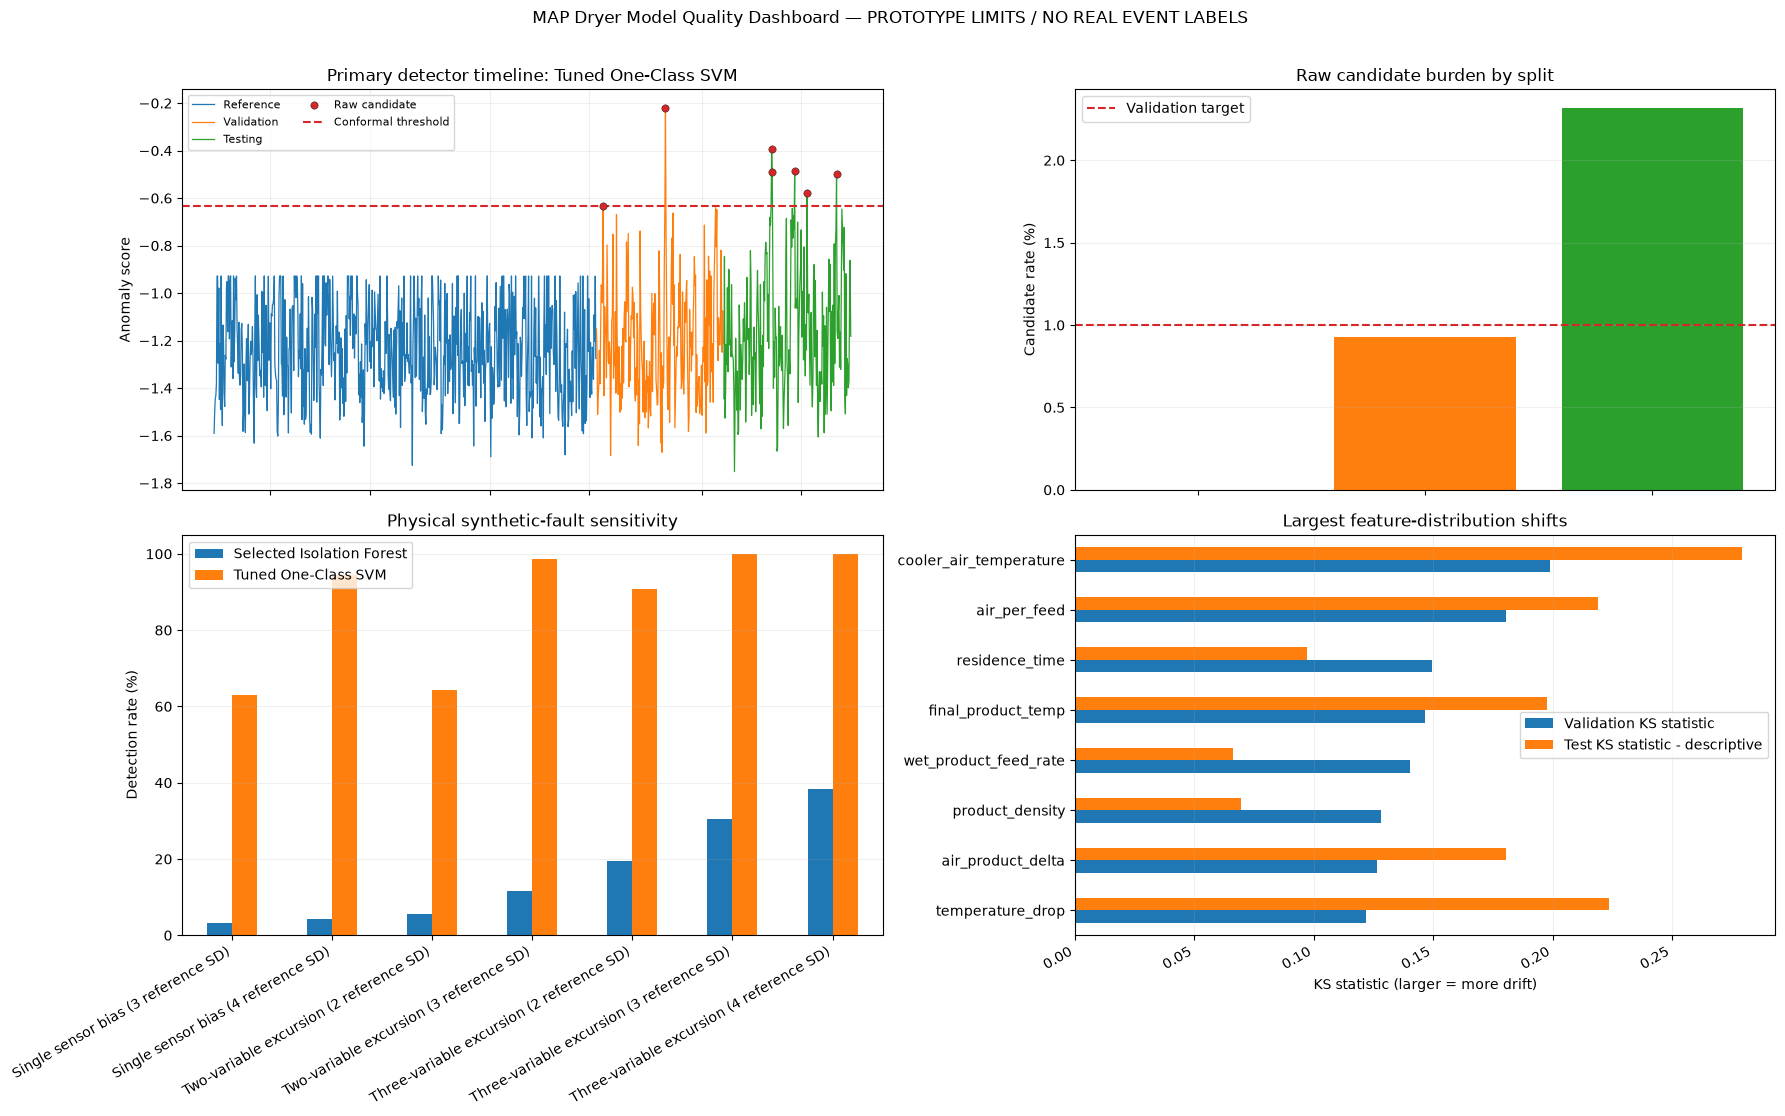

In [23]:
provisional_split_quality = (
    provisional_selected_score_results.groupby("Split", sort=False)
    .agg(
        Observations=("Anomaly score", "size"),
        Raw_candidates=("Raw anomaly flag", "sum"),
        Persistent_alarm_observations=("Persistent alarm", "sum"),
        Persistent_alarm_episodes=("Alarm episode", "nunique"),
    )
)
provisional_split_quality["Raw candidate rate (%)"] = (
    100
    * provisional_split_quality["Raw_candidates"]
    / provisional_split_quality["Observations"]
)
provisional_split_quality["Persistent alarm rate (%)"] = (
    100
    * provisional_split_quality["Persistent_alarm_observations"]
    / provisional_split_quality["Observations"]
)

final_quality_summary = pd.Series(
    {
        "Provisional primary detector": PROVISIONAL_SELECTED_DETECTOR,
        "Normal-reference rows": len(X_normal_reference),
        "Prototype PCS7 rows excluded from training": int(
            (~pcs7_reference_eligible_rows).sum()
        ),
        "Target validation raw candidate rate (%)": (
            100 * TARGET_VALIDATION_CANDIDATE_RATE
        ),
        "Observed validation raw candidate rate (%)": (
            provisional_split_quality.loc["Validation", "Raw candidate rate (%)"]
        ),
        "Test raw candidate rate (%) - descriptive": (
            provisional_split_quality.loc["Testing", "Raw candidate rate (%)"]
        ),
        "Mean synthetic scenario detection rate (%)": (
            100 * provisional_selected_synthetic_detection.mean()
        ),
        "Worst synthetic scenario detection rate (%)": (
            100 * provisional_selected_synthetic_detection.min()
        ),
        "Confirmed real-event labels available": False,
        "PCS7 limits approved": PCS7_LIMITS_APPROVED,
    },
    name="Model quality status",
)
display(final_quality_summary.to_frame())
display(provisional_split_quality.round(4))

fig, axes = plt.subplots(2, 2, figsize=(18, 11))
timeline_axis = axes[0, 0]
for split_name, split_color in split_colors.items():
    split_rows = provisional_selected_score_results.loc[
        provisional_selected_score_results["Split"] == split_name
    ]
    timeline_axis.plot(
        split_rows["timestamp"],
        split_rows["Anomaly score"],
        color=split_color,
        linewidth=0.9,
        label=split_name,
    )
selected_candidates = provisional_selected_score_results.loc[
    provisional_selected_score_results["Raw anomaly flag"]
]
timeline_axis.scatter(
    selected_candidates["timestamp"],
    selected_candidates["Anomaly score"],
    color="tab:red",
    edgecolor="black",
    linewidth=0.3,
    s=28,
    zorder=4,
    label="Raw candidate",
)
timeline_axis.axhline(
    PROVISIONAL_SELECTED_THRESHOLD,
    color="tab:red",
    linestyle="--",
    label="Conformal threshold",
)
timeline_axis.set_title(f"Primary detector timeline: {PROVISIONAL_SELECTED_DETECTOR}")
timeline_axis.set_ylabel("Anomaly score")
timeline_axis.legend(fontsize=8, ncol=2)
timeline_axis.grid(alpha=0.2)

candidate_rates = provisional_split_quality["Raw candidate rate (%)"]
axes[0, 1].bar(candidate_rates.index, candidate_rates.values, color=list(split_colors.values()))
axes[0, 1].axhline(
    100 * TARGET_VALIDATION_CANDIDATE_RATE,
    color="tab:red",
    linestyle="--",
    label="Validation target",
)
axes[0, 1].set_title("Raw candidate burden by split")
axes[0, 1].set_ylabel("Candidate rate (%)")
axes[0, 1].legend()
axes[0, 1].grid(axis="y", alpha=0.2)

synthetic_detector_comparison.plot(kind="bar", ax=axes[1, 0])
axes[1, 0].set_title("Physical synthetic-fault sensitivity")
axes[1, 0].set_ylabel("Detection rate (%)")
axes[1, 0].set_xlabel("")
axes[1, 0].tick_params(axis="x", rotation=35)
axes[1, 0].grid(axis="y", alpha=0.2)

top_feature_drift = feature_drift_evaluation.head(8)[
    ["Validation KS statistic", "Test KS statistic - descriptive"]
].sort_values("Validation KS statistic")
top_feature_drift.plot(kind="barh", ax=axes[1, 1])
axes[1, 1].set_title("Largest feature-distribution shifts")
axes[1, 1].set_xlabel("KS statistic (larger = more drift)")
axes[1, 1].set_ylabel("")
axes[1, 1].grid(axis="x", alpha=0.2)

fig.suptitle(
    "MAP Dryer Model Quality Dashboard — PROTOTYPE LIMITS / NO REAL EVENT LABELS",
    y=1.01,
)
fig.autofmt_xdate()
fig.tight_layout()
fig.savefig(
    FIGURE_OUTPUT_DIR / "07_model_quality_dashboard.png",
    dpi=300,
    bbox_inches="tight",
)
plt.show()

## 28-29. Configure the diagnostic layer and build the train-only reference profile

The detector remains unchanged. The diagnostic branch loads versioned feature, subsystem, rule, and threshold configuration, then builds robust medians, IQR/MAD values, quantiles, and temporal delta statistics from the same chronological `X_normal_reference` used to fit the detector. Delayed laboratory moisture is excluded from all online inputs.

Diagnostic language is deliberately cautious: diagnoses are **probable**, causes are **suspected**, and no mechanical root cause is treated as confirmed without operator or maintenance evidence.

In [24]:
from anomaly.scoring import canonical_anomaly_score
from diagnosis.bundle import save_diagnostic_bundle_metadata
from diagnosis.config import (
    load_diagnostic_configuration,
    validate_model_features,
)
from diagnosis.engine import diagnose_anomaly, format_operator_report
from diagnosis.reference_profile import build_reference_profile
from diagnosis.scenarios import build_physical_scenarios

DIAGNOSTIC_CONFIG_DIR = PROJECT_ROOT / "config"
DIAGNOSIS_FIGURE_OUTPUT_DIR = FIGURES_DIR / "05_Model3_Process_Diagnosis"
DIAGNOSIS_FIGURE_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

diagnostic_configuration = load_diagnostic_configuration(
    DIAGNOSTIC_CONFIG_DIR
)
validate_model_features(
    MODEL_FEATURES,
    diagnostic_configuration["feature_metadata"],
)
reference_profile = build_reference_profile(
    X_normal_reference,
    diagnostic_configuration["feature_metadata"],
)

feature_metadata_table = (
    pd.DataFrame.from_dict(
        diagnostic_configuration["feature_metadata"]["features"],
        orient="index",
    )
    .rename_axis("Feature")
    .loc[MODEL_FEATURES]
)
reference_profile_table = pd.DataFrame(reference_profile.statistics).T[
    ["median", "iqr", "mad", "q05", "q95", "delta_iqr"]
]

display(feature_metadata_table)
display(reference_profile_table.round(4))
print("Diagnostic configuration versions:", diagnostic_configuration["versions"])
print("Reference-profile rows (training only):", reference_profile.training_rows)

,unit,kind,parents,subsystems,criticality,online_available,explanation_group
Feature,,,,,,,
dryer_air_temperature,degC,raw,[],[thermal_system],high,True,dryer_temperature
cooler_air_temperature,degC,raw,[],[cooling_system],medium,True,cooler_temperature
air_flow_rate,process_unit,raw,[],[drying_air_exhaust],high,True,air_supply
wet_product_feed_rate,process_unit,raw,[],[feed_loading],high,True,feed_loading
product_inlet_temperature,degC,raw,[],"[feed_loading, thermal_system]",medium,True,inlet_temperature
residence_time,process_unit,raw,[],[feed_loading],medium,True,residence_time
vacuum,process_unit,raw,[],[drying_air_exhaust],high,True,exhaust_pressure
steam_pressure,process_unit,raw,[],[thermal_system],high,True,steam_supply
fan_speed,rpm,raw,[],[drying_air_exhaust],high,True,air_supply


,median,iqr,mad,q05,q95,delta_iqr
dryer_air_temperature,139.5000,1.7000,0.8000,137.7000,141.3000,1.2000
cooler_air_temperature,23.4500,5.5000,2.6500,18.5000,28.3650,2.6000
air_flow_rate,23.8050,1.1625,0.5950,22.4635,25.1565,1.0250
wet_product_feed_rate,10.1850,0.6925,0.3450,9.5300,10.7900,0.1600
product_inlet_temperature,47.5000,2.0000,1.0000,45.1000,49.9000,1.7000
residence_time,20.5800,0.9025,0.4550,19.3900,21.5865,0.7100
vacuum,-0.9400,0.5000,0.2450,-1.5765,-0.4500,0.4000
steam_pressure,4.8000,0.2100,0.1100,4.5100,5.0765,0.2300
fan_speed,1261.0000,45.2500,23.0000,1211.0000,1313.0000,37.0000
product_density,1.0270,0.0060,0.0030,1.0180,1.0350,0.0100


Diagnostic configuration versions: {'feature_metadata': 'diag_features_v1.0', 'subsystems': 'diag_subsystems_v1.0', 'thresholds': 'diag_thresholds_v1.0', 'rules': 'diag_rules_v1.0'}
Reference-profile rows (training only): 648


## 30-34. Verify localization, temporal, subsystem, rule, confidence, severity, and instrumentation contracts

The reusable modules apply two complementary localization signals: robust deviation from train-only medians/IQRs and counterfactual One-Class SVM sensitivity. Feature attributions are normalized, mapped to physical subsystems without double counting, combined with recent temporal patterns, and evaluated through the configured D01-D08 rules. Diagnostic confidence describes rule agreement; severity is a separate model-based operational indicator and is not a safety classification.

The check below proves that the canonical scoring helper reproduces the notebook's existing OCSVM scores exactly. Diagnosis therefore adds no retuning or detector-output change.

In [25]:
ocsvm_scaled_timeline = pd.concat(
    [X_train_scaled, X_validation_scaled, X_test_scaled],
    axis=0,
).sort_index()
canonical_ocsvm_scores = canonical_anomaly_score(
    one_class_svm_model,
    ocsvm_scaled_timeline[MODEL_FEATURES],
)
stored_ocsvm_scores = (
    one_class_svm_score_results
    .sort_values("timestamp", kind="stable")["Anomaly score"]
    .to_numpy()
)
if not np.allclose(canonical_ocsvm_scores, stored_ocsvm_scores):
    raise AssertionError(
        "The diagnosis score adapter changed the existing OCSVM score contract."
    )

diagnostic_contract = pd.Series(
    {
        "Detector preserved": "Tuned One-Class SVM",
        "Score convention": "Higher score = more abnormal",
        "Detector score equality": True,
        "Feature localization": "40% robust deviation + 60% counterfactual sensitivity",
        "Configured diagnostic rules": len(
            diagnostic_configuration["rules"]["rules"]
        ),
        "Instrumentation guard": "Enabled",
        "Lab moisture used online": False,
    },
    name="Diagnostic contract",
)
display(diagnostic_contract.to_frame())

,Diagnostic contract
Detector preserved,Tuned One-Class SVM
Score convention,Higher score = more abnormal
Detector score equality,True
Feature localization,40% robust deviation + 60% counterfactual sens...
Configured diagnostic rules,8
Instrumentation guard,Enabled
Lab moisture used online,False


## 35. Diagnose persistent validation/test episodes and produce operator-safe events

One representative observation is selected per persistent alarm episode: the observation with the highest OCSVM anomaly score. The engine uses only history available at that timestamp. It returns a stable `DiagnosticEvent` with ranked evidence, subsystem scores, temporal patterns, probable diagnoses, suspected causes, recommended checks, severity, confidence, configuration versions, and empty operator-confirmation fields.

,Event ID,Timestamp,Severity,Primary subsystem,Probable diagnosis,Confidence,Top feature,Retrospective lab moisture,Operator status
0,MAPD-263B00C33675D26D,2026-07-10 21:00:00,MODERATE,thermal_system,Abnormal exhaust or pressure condition,0.72,product_inlet_temperature,0.085,UNREVIEWED


ANOMALY DETECTED | Severity: MODERATE | Primary subsystem: thermal_system | Probable diagnosis: Abnormal exhaust or pressure condition | Confidence: 72% (HIGH). Observed evidence: product_inlet_temperature HIGH (25%), air_product_delta LOW (18%), cooler_air_temperature HIGH (15%). Suspected causes requiring verification: Exhaust fan problem, Duct restriction, Damper-position problem. Recommended checks: Verify the vacuum measurement; Inspect the exhaust fan and duct restrictions; Check dampers and leak paths. Model-based operational severity; not a safety classification.



,feature,direction,current_value,reference_median,robust_z,robust_deviation,counterfactual_contribution,attribution,unit,kind,parents,subsystems,criticality,explanation_group
0,product_inlet_temperature,HIGH,50.50,47.50,1.5000,1.5000,0.3722,0.2522,degC,raw,[],"[feed_loading, thermal_system]",medium,inlet_temperature
1,air_product_delta,LOW,86.80,91.90,-1.9615,1.9615,0.2388,0.1811,degC,engineered,"[dryer_air_temperature, product_inlet_temperat...","[thermal_system, feed_loading]",medium,inlet_temperature
2,cooler_air_temperature,HIGH,32.80,23.45,1.7000,1.7000,0.1891,0.1462,degC,raw,[],[cooling_system],medium,cooler_temperature
3,temperature_drop,HIGH,101.30,96.20,2.1250,2.1250,0.0901,0.0950,degC,engineered,"[dryer_air_temperature, final_product_temp]","[thermal_system, cooling_system]",medium,dryer_temperature
4,residence_time,NORMAL,19.57,20.58,-1.1191,1.1191,0.0687,0.0628,process_unit,raw,[],[feed_loading],medium,residence_time


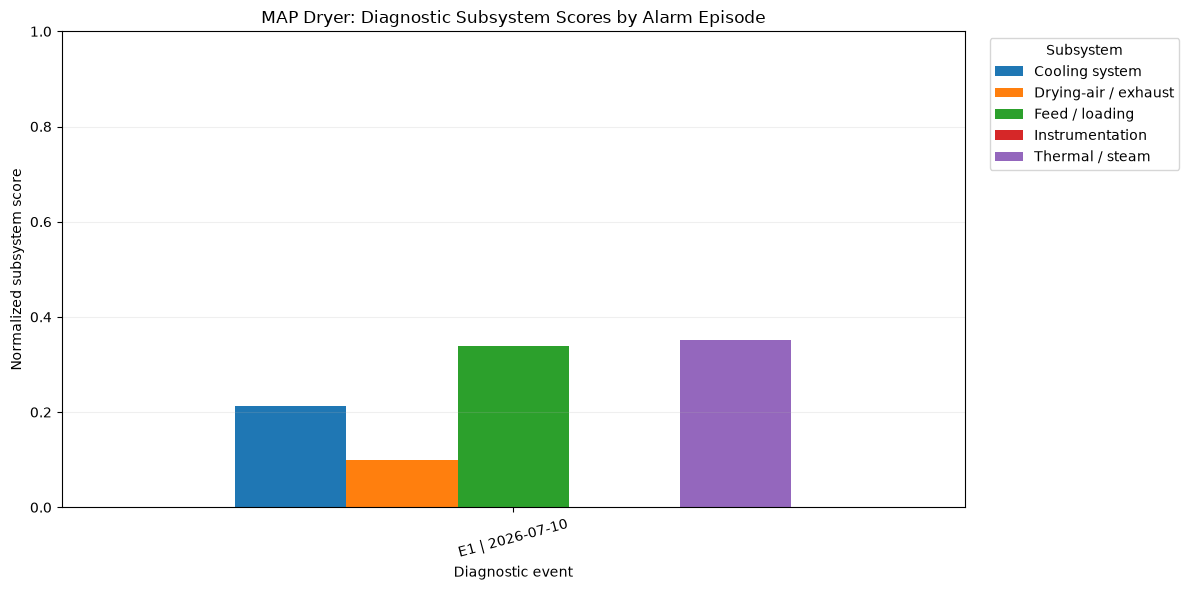

In [26]:
import json

diagnostic_score_results = one_class_svm_score_results.copy()
episode_rows = diagnostic_score_results.loc[
    diagnostic_score_results["Persistent alarm"]
    & diagnostic_score_results["Split"].isin(["Validation", "Testing"])
    & diagnostic_score_results["Alarm episode"].notna()
].copy()

if episode_rows.empty:
    representative_rows = diagnostic_score_results.loc[
        diagnostic_score_results["Raw anomaly flag"]
        & diagnostic_score_results["Split"].isin(["Validation", "Testing"])
    ].copy()
else:
    representative_indices = episode_rows.groupby(
        ["Split", "Alarm episode"], sort=False
    )["Anomaly score"].idxmax()
    representative_rows = diagnostic_score_results.loc[
        representative_indices
    ].sort_values("timestamp", kind="stable")

history_window = int(
    diagnostic_configuration["thresholds"]["temporal"]["history_window"]
)
diagnostic_events = []
for _, representative in representative_rows.iterrows():
    event_timestamp = pd.Timestamp(representative["timestamp"])
    history = ordered_anomaly_data.loc[
        ordered_anomaly_data["timestamp"] <= event_timestamp,
        MODEL_FEATURES,
    ].tail(history_window)
    current = history.iloc[-1]
    pcs7_row = pcs7_limit_results.loc[
        pcs7_limit_results["timestamp"] == event_timestamp
    ].iloc[0]
    lab_moisture = dryerMAP_model.loc[
        dryerMAP_model["timestamp"] == event_timestamp,
        "final_moisture_h₂o",
    ].iloc[0]
    diagnostic_events.append(
        diagnose_anomaly(
            timestamp=event_timestamp,
            anomaly=True,
            anomaly_score=representative["Anomaly score"],
            threshold=ONE_CLASS_SVM_THRESHOLD,
            x_current=current,
            history_df=history,
            model=one_class_svm_model,
            scaler=anomaly_scaler,
            reference_profile=reference_profile,
            feature_metadata=diagnostic_configuration["feature_metadata"],
            subsystem_config=diagnostic_configuration["subsystems"],
            rule_config=diagnostic_configuration["rules"],
            threshold_config=diagnostic_configuration["thresholds"],
            config_versions=diagnostic_configuration["versions"],
            approved_limit_crossing=(
                PCS7_LIMITS_APPROVED and bool(pcs7_row["PCS7 rule breach"])
            ),
            lab_moisture_after_event=float(lab_moisture),
            notes="Retrospective prototype diagnosis; operator evidence unavailable.",
        )
    )

diagnostic_event_summary = pd.DataFrame(
    [
        {
            "Event ID": event.event_id,
            "Timestamp": event.timestamp,
            "Severity": event.severity,
            "Primary subsystem": event.primary_subsystem,
            "Probable diagnosis": (
                event.diagnoses[0].diagnosis
                if event.diagnoses
                else "Insufficient diagnostic evidence"
            ),
            "Confidence": (
                event.diagnoses[0].confidence if event.diagnoses else np.nan
            ),
            "Top feature": (
                event.top_features[0].feature if event.top_features else None
            ),
            "Retrospective lab moisture": event.lab_moisture_after_event,
            "Operator status": event.operator_status,
        }
        for event in diagnostic_events
    ]
)
display(diagnostic_event_summary.round({"Confidence": 3}))
for event in diagnostic_events:
    print(format_operator_report(event))
    print()

if diagnostic_events:
    first_event_evidence = pd.DataFrame(
        [item.as_dict() for item in diagnostic_events[0].top_features]
    )
    display(first_event_evidence.round(4))

    subsystem_score_table = pd.DataFrame(
        [event.subsystem_scores for event in diagnostic_events],
        index=[
            f"E{event_index + 1} | {pd.Timestamp(event.timestamp):%Y-%m-%d}"
            for event_index, event in enumerate(diagnostic_events)
        ],
    ).fillna(0.0)
    subsystem_display_names = {
        name: details["display_name"]
        for name, details in diagnostic_configuration["subsystems"][
            "subsystems"
        ].items()
    }
    subsystem_score_table = subsystem_score_table.rename(
        columns=subsystem_display_names
    )
    axis = subsystem_score_table.plot(
        kind="bar",
        figsize=(12, 6),
        width=0.8,
    )
    axis.set_title("MAP Dryer: Diagnostic Subsystem Scores by Alarm Episode")
    axis.set_xlabel("Diagnostic event")
    axis.set_ylabel("Normalized subsystem score")
    axis.set_ylim(0, 1)
    axis.tick_params(axis="x", rotation=15)
    axis.grid(axis="y", alpha=0.2)
    axis.legend(title="Subsystem", bbox_to_anchor=(1.02, 1), loc="upper left")
    axis.figure.tight_layout()
    axis.figure.savefig(
        DIAGNOSIS_FIGURE_OUTPUT_DIR / "01_episode_subsystem_scores.png",
        dpi=300,
        bbox_inches="tight",
    )
    plt.show()

## 36. Run coherent physical scenarios and the deterministic unit suite

The eight scenarios modify raw process measurements first, recompute all engineered features, apply the unchanged OCSVM detector, and then invoke diagnosis. Acceptance requires every scenario to be detected and its expected D01-D08 rule to be returned; isolated temperature jumps and stuck signals must resolve to instrumentation diagnoses.

,Injected behavior,Anomaly score,Detected,Expected rule,Top returned rule,Expected rule returned
Scenario,,,,,,
S01,Airflow loss,-0.0926,True,D01,D01,True
S02,Steam loss,-0.0340,True,D02,D02,True
S03,Feed overload,-0.0032,True,D03,D03,True
S04,Cooling degradation,-0.0036,True,D04,D04,True
S05,Exhaust restriction,-0.0246,True,D05,D05,True
S06,Temperature sensor jump,-0.0001,True,D06,D06,True
S07,Stuck fan-speed signal,-0.2732,True,D07,D07,True
S08,Oscillatory control,-0.0465,True,D08,D05,True


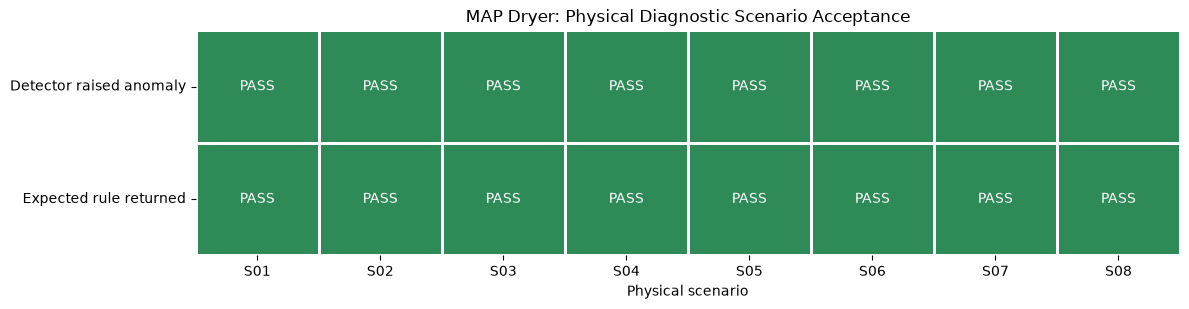


----------------------------------------------------------------------
Ran 20 tests in 0.868s

OK



In [27]:
import os
import subprocess

physical_scenarios = build_physical_scenarios(reference_profile)
scenario_rows = []
for scenario_id, scenario in physical_scenarios.items():
    scenario_score = float(
        canonical_anomaly_score(
            one_class_svm_model,
            anomaly_scaler.transform(
                scenario.current.to_frame().T[MODEL_FEATURES]
            ),
        )[0]
    )
    detected = scenario_score >= ONE_CLASS_SVM_THRESHOLD
    scenario_event = diagnose_anomaly(
        timestamp=pd.Timestamp("2030-01-01")
        + pd.Timedelta(hours=2 * int(scenario_id[1:])),
        anomaly=detected,
        anomaly_score=scenario_score,
        threshold=ONE_CLASS_SVM_THRESHOLD,
        x_current=scenario.current,
        history_df=scenario.history,
        model=one_class_svm_model,
        scaler=anomaly_scaler,
        reference_profile=reference_profile,
        feature_metadata=diagnostic_configuration["feature_metadata"],
        subsystem_config=diagnostic_configuration["subsystems"],
        rule_config=diagnostic_configuration["rules"],
        threshold_config=diagnostic_configuration["thresholds"],
        config_versions=diagnostic_configuration["versions"],
    )
    returned_rules = [result.rule_id for result in scenario_event.diagnoses]
    scenario_rows.append(
        {
            "Scenario": scenario_id,
            "Injected behavior": scenario.name,
            "Anomaly score": scenario_score,
            "Detected": detected,
            "Expected rule": scenario.expected_rule_id,
            "Top returned rule": returned_rules[0] if returned_rules else None,
            "Expected rule returned": scenario.expected_rule_id in returned_rules,
        }
    )

scenario_acceptance = pd.DataFrame(scenario_rows).set_index("Scenario")
if not scenario_acceptance["Detected"].all():
    raise AssertionError("At least one physical scenario was not detected by OCSVM.")
if not scenario_acceptance["Expected rule returned"].all():
    raise AssertionError("At least one physical scenario missed its expected rule.")
if scenario_acceptance.loc["S06", "Top returned rule"] != "D06":
    raise AssertionError("Instrumentation jump did not outrank process-fault rules.")
if scenario_acceptance.loc["S07", "Top returned rule"] != "D07":
    raise AssertionError("Stuck-sensor diagnosis did not rank first.")
display(scenario_acceptance.round({"Anomaly score": 4}))

acceptance_plot = scenario_acceptance[
    ["Detected", "Expected rule returned"]
].astype(int).T
acceptance_plot.index = ["Detector raised anomaly", "Expected rule returned"]
figure, axis = plt.subplots(figsize=(12, 3.2))
sns.heatmap(
    acceptance_plot,
    annot=acceptance_plot.replace({1: "PASS", 0: "FAIL"}),
    fmt="",
    cmap=sns.color_palette(["#c0392b", "#2e8b57"], as_cmap=True),
    vmin=0,
    vmax=1,
    cbar=False,
    linewidths=1,
    linecolor="white",
    ax=axis,
)
axis.set_title("MAP Dryer: Physical Diagnostic Scenario Acceptance")
axis.set_xlabel("Physical scenario")
axis.set_ylabel("")
axis.tick_params(axis="x", rotation=0)
axis.tick_params(axis="y", rotation=0)
figure.tight_layout()
figure.savefig(
    DIAGNOSIS_FIGURE_OUTPUT_DIR / "02_physical_scenario_acceptance.png",
    dpi=300,
    bbox_inches="tight",
)
plt.show()

test_environment = os.environ.copy()
test_environment["PYTHONPATH"] = str(SRC_DIR)
unit_test_run = subprocess.run(
    [sys.executable, "-m", "unittest", "discover", "-s", "tests", "-q"],
    cwd=PROJECT_ROOT,
    env=test_environment,
    capture_output=True,
    text=True,
    check=False,
)
print(unit_test_run.stdout)
print(unit_test_run.stderr)
if unit_test_run.returncode != 0:
    raise AssertionError("The deterministic diagnostic unit suite failed.")

## 37-38. Retrospective evidence, event export, and versioned deployment metadata

Laboratory moisture is attached only after diagnosis as retrospective evidence; it never enters model fitting, scoring, localization, rules, or severity. Operator and maintenance labels are not yet available, so the probable diagnoses remain unconfirmed. The final cell exports JSON events and a metadata bundle containing the detector score contract, threshold, train-only profile, exact feature order, configuration versions, and configuration hashes.

In [28]:
DIAGNOSTIC_MODEL_OUTPUT_DIR = PROJECT_ROOT / "models" / "diagnosis"
DIAGNOSTIC_MODEL_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

diagnostic_events_path = (
    DIAGNOSTIC_MODEL_OUTPUT_DIR
    / "validation_test_diagnostic_events.diag_v1.0.json"
)
diagnostic_events_path.write_text(
    json.dumps(
        [event.as_dict() for event in diagnostic_events],
        indent=2,
        sort_keys=True,
    ),
    encoding="utf-8",
)

diagnostic_bundle_path = save_diagnostic_bundle_metadata(
    DIAGNOSTIC_MODEL_OUTPUT_DIR / "diagnostic_bundle_metadata.diag_v1.0.json",
    detector_name="Tuned One-Class SVM",
    detector_parameters=best_one_class_svm_parameters,
    anomaly_threshold=ONE_CLASS_SVM_THRESHOLD,
    model_features=MODEL_FEATURES,
    reference_profile=reference_profile,
    config_versions=diagnostic_configuration["versions"],
    config_hashes=diagnostic_configuration["hashes"],
    diagnostic_version=diagnostic_configuration["thresholds"][
        "diagnostic_version"
    ],
)
feedback_template_path = (
    PROJECT_ROOT / "data" / "reference" / "diagnostic_event_history_template.csv"
)

deployment_outputs = pd.Series(
    {
        "Diagnostic events JSON": diagnostic_events_path,
        "Diagnostic bundle metadata": diagnostic_bundle_path,
        "Operator feedback template": feedback_template_path,
        "Configuration versions": diagnostic_configuration["versions"],
        "Reference rows": reference_profile.training_rows,
        "Lab moisture used online": False,
        "Confirmed event labels available": False,
    },
    name="Deployment output",
)
display(deployment_outputs.to_frame())

,Deployment output
Diagnostic events JSON,c:\Users\pc\Documents\GitHub\PROJECTS\MAP-Drye...
Diagnostic bundle metadata,c:\Users\pc\Documents\GitHub\PROJECTS\MAP-Drye...
Operator feedback template,c:\Users\pc\Documents\GitHub\PROJECTS\MAP-Drye...
Configuration versions,"{'feature_metadata': 'diag_features_v1.0', 'su..."
Reference rows,648
Lab moisture used online,False
Confirmed event labels available,False


## Diagnostic-layer status and required next evidence

The modular diagnostic layer now satisfies the specification's implementation scope: unchanged OCSVM detection, train-only profiling, dual-signal localization, normalized subsystem scoring, temporal analysis, configurable D01-D08 rules, instrumentation discrimination, separate confidence/severity, deterministic JSON events, coherent scenario validation, unit tests, feedback fields, and versioned deployment metadata.

The result remains a **prototype decision-support system**. Production approval still requires approved PCS7 operating limits, higher-frequency historian data with time-based persistence recalibration, operator/maintenance-confirmed event labels, and event-level historical validation. Until that evidence exists, diagnoses are probable and listed causes are suspected checks—not confirmed root causes.

## Next task

Collect operator- and maintenance-confirmed event outcomes using the versioned feedback schema, replace prototype PCS7 limits with approved values, and rerun event-level chronological validation before any production deployment or supervised fault classifier is considered.